# Indicador biologico fenologico de brotacion / ELP4 - v2

## 1. Objetivo y alcance

Este notebook queda separado del baseline historico y del flujo
de Luis/madurez tecnica.

- El baseline original sigue en `multisite_multivariety_gdd_analysis.ipynb`.
- La pregunta de esta v2 es distinta: con toda la informacion fenologica
  disponible, observada, interpolada o modelada con trazabilidad,
  cual es la mejor combinacion `fundo-variedad` para construir un
  indicador biologico alternativo sin esconder `NaN`, sin tolerar
  `GDD = 0` silenciosos y con soporte multivarietal real en el mismo fundo.

## 2. Inputs y fuentes

- `reports/phenology/elp4_cleaning_report.csv`
- `data/prepared/phenology_climate_clean/`
- `models/pheno_modeling-main` como apoyo auxiliar
- `models/indicador_biologico/outputs_multisite_gdd/` como referencia historica

## 3. Logica metodologica de esta v2 corregida

1. cargar la auditoria original de ELP4 y todas las series limpias;
2. recalificar cada caso como `observado`, `interpolado_cercano`,
   `modelado_con_observacion_cercana`, `modelado_sin_observacion_cercana`
   o `no_evaluable`;
3. usar `pheno_modeling-main` solo donde realmente aporta:
   hoy como apoyo para `cabernet_sauvignon` y `chardonnay`;
4. construir una auditoria fenologica completa por `fundo-variedad-temporada`;
5. rankear candidatos con cobertura, calidad del ELP4 y soporte
   multivarietal del fundo;
6. fijar un umbral GDD comunicable terminado en `0` o `5`, con metricas;
7. reconstruir `t0` por fundo/temporada y luego `t0` operativo por fundo;
8. diagnosticar la senal latitudinal por separado para brotacion, `t0` crudo
   y `t0` operativo;
9. exportar reportes y figuras del indicador biologico, sin mezclar este
   flujo con datasets de modelacion para madurez tecnica o entregables a Luis.

In [1]:
from pathlib import Path
import importlib.util
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

ROOT = Path.cwd()
while ROOT.name != "vendimia_5_0_obj3" and ROOT.parent != ROOT:
    ROOT = ROOT.parent

QA_ELP4_FILE = ROOT / "reports" / "phenology" / "elp4_cleaning_report.csv"
LOURDES_CS_RECALC = ROOT / "reports" / "phenology" / "lourdes_cabernet_sauvignon_gdd_recalculated.csv"
BASELINE_T0_FILE = ROOT / "models" / "indicador_biologico" / "outputs_multisite_gdd" / "method_pipeline_cs_t0_operativo_by_fundo.csv"
BASELINE_VAR_FILE = ROOT / "models" / "indicador_biologico" / "outputs_multisite_gdd" / "method_pipeline_varietal_evaluation_by_fundo.csv"
BASELINE_REF_FILE = ROOT / "models" / "indicador_biologico" / "outputs_multisite_gdd" / "method_pipeline_lourdes_varietal_reference.csv"
PHENO_MODEL_ROOT = ROOT / "models" / "pheno_modeling-main"

REPORT_BIO_DIR = ROOT / "reports" / "phenology" / "indicador_biologico"
FIG_DIR = ROOT / "models" / "indicador_biologico" / "figures"
REPORT_BIO_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TB = 10.0
TU = 35.0
ELP_FINAL = 38.0
TARGET_ELP4 = 4.0
CURRENT_SEASON = "2025_2026"
REGRESSION_EXCLUDED_FUNDS = {"los_acacios"}
KEULE_ALT_BIOFIX_LABEL = "1-agosto"
KEULE_ALT_BIOFIX_MONTH = 8
KEULE_ALT_BIOFIX_DAY = 1
KEULE_ALT_GDD_THRESHOLD = 150
LOCAL_FUNDS = ["idahue", "keule", "los_acacios", "lourdes", "nilahue", "qba_seca", "ucuquer"]
VARIETIES = ["cabernet_sauvignon", "chardonnay", "carmenere", "sauvignon_blanc"]
SUPPORTED_PHENO_MODEL_VARIETIES = ["cabernet_sauvignon", "chardonnay"]
CANDIDATE_THRESHOLDS = [45, 50, 55, 60, 65, 70, 75, 80]
BIOFIX_CANDIDATES = [
    ("15-julio", (7, 15)),
    ("1-agosto", (8, 1)),
    ("15-agosto", (8, 15)),
    ("1-septiembre", (9, 1)),
]

FUNDO_ALIASES = {
    "quebrada_seca": "qba_seca",
    "quebrada seca": "qba_seca",
    "qba_seca": "qba_seca",
    "quebrada_de_agua": "qba_seca",
    "los acacios": "los_acacios",
    "huertos de ucuquer": "ucuquer",
    "huertos_de_ucuquer": "ucuquer",
}

FUNDO_DISPLAY = {
    "qba_seca": "Quebrada Seca",
    "los_acacios": "Los Acacios",
    "ucuquer": "Ucuquer",
    "idahue": "Idahue",
    "nilahue": "Nilahue",
    "lourdes": "Lourdes",
    "keule": "Keule",
}

FUNDO_LAT = {
    "qba_seca": -30.527298,
    "los_acacios": -30.695498,
    "ucuquer": -33.984690,
    "idahue": -34.501161,
    "nilahue": -34.704042,
    "lourdes": -35.449590,
    "keule": -35.868577,
}

In [2]:
def normalize_fundo(value):
    text = str(value).strip().lower()
    text = re.sub(r"\s+", " ", text).replace(" ", "_")
    return FUNDO_ALIASES.get(text, text)

def season_biofix(temporada, month, day):
    return pd.Timestamp(year=int(str(temporada).split("_")[0]), month=month, day=day)

def season_sep1(temporada):
    return season_biofix(temporada, 9, 1)

def season_from_sheet(sheet_name):
    match = re.search(r"(20\d{2})\D+(20\d{2})", str(sheet_name))
    if match:
        return f"{match.group(1)}_{match.group(2)}"
    return None

def date_from_season_doy(temporada, doy):
    year = int(str(temporada).split("_")[0])
    return pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=int(round(doy)) - 1)

def gdd_seno_simple(tmax, tmin, tb=TB, tu=TU):
    if pd.isna(tmax) or pd.isna(tmin):
        return np.nan
    tmean = (tmax + tmin) / 2
    alpha = (tmax - tmin) / 2
    if alpha == 0:
        return max(0, min(tmean, tu) - tb)
    if tmax <= tb:
        return 0.0
    if tmin >= tu:
        return tu - tb
    if tmin >= tb and tmax <= tu:
        return tmean - tb
    if tmin < tb and tmax <= tu:
        theta = np.arcsin((tb - tmean) / alpha)
        return (((tmean - tb) * (np.pi / 2 - theta)) + (alpha * np.cos(theta))) / np.pi
    if tmin >= tb and tmax > tu:
        theta = np.arcsin((tu - tmean) / alpha)
        return (((tmean - tb) * (theta + np.pi / 2)) + (alpha * np.cos(theta)) + ((tu - tb) * (np.pi / 2 - theta))) / np.pi
    if tmin < tb and tmax > tu:
        theta1 = np.arcsin((tb - tmean) / alpha)
        theta2 = np.arcsin((tu - tmean) / alpha)
        return (((tmean - tb) * (theta2 - theta1)) + (alpha * (np.cos(theta1) - np.cos(theta2))) + ((tu - tb) * (np.pi / 2 - theta2))) / np.pi
    return np.nan

def add_gdd(df):
    out = df.copy()
    out["gdd_diario"] = [gdd_seno_simple(tmax, tmin) for tmax, tmin in zip(out["temp_max_grado_c"], out["temp_min_grado_c"])]
    return out

def accumulated_gdd(df, t0, end_date):
    if pd.isna(t0) or pd.isna(end_date):
        return np.nan
    sub = df[(df["Fecha"] >= t0) & (df["Fecha"] <= end_date)].copy()
    if sub.empty:
        return np.nan
    return float(add_gdd(sub)["gdd_diario"].sum())

def first_date_reaching_gdd(df, t0, gdd_required):
    if pd.isna(t0) or pd.isna(gdd_required):
        return pd.NaT
    sub = df[df["Fecha"] >= t0].sort_values("Fecha").copy()
    if sub.empty:
        return pd.NaT
    sub = add_gdd(sub)
    sub["gdd_acum"] = sub["gdd_diario"].cumsum()
    reached = sub[sub["gdd_acum"] >= gdd_required]
    if reached.empty:
        return pd.NaT
    return reached.iloc[0]["Fecha"]

def infer_t0_for_target_date(df, target_date, gdd_required):
    if pd.isna(target_date) or pd.isna(gdd_required):
        return None
    year = int(pd.Timestamp(target_date).year)
    candidates = pd.date_range(start=f"{year}-07-01", end=pd.Timestamp(target_date), freq="D")
    best = None
    for t0 in candidates:
        gdd_at_target = accumulated_gdd(df, t0, target_date)
        estimated_date = first_date_reaching_gdd(df, t0, gdd_required)
        if pd.isna(gdd_at_target) or pd.isna(estimated_date):
            continue
        error = abs(gdd_at_target - gdd_required)
        error_days = int((pd.Timestamp(target_date) - estimated_date).days)
        score = (abs(error_days), error)
        if best is None or score < best["score"]:
            best = {
                "t0_estimado": t0,
                "doy_t0": int(t0.dayofyear),
                "gdd_estimado": float(gdd_at_target),
                "error_gdd": float(error),
                "fecha_estimacion_ref": estimated_date,
                "error_dias": error_days,
                "score": score,
            }
    return best

def fit_subset_predict_all(df, fit_mask, x_col, y_col, pred_col, resid_col):
    out = df.copy()
    out[pred_col] = np.nan
    out[resid_col] = np.nan
    fit = out[fit_mask & out[[x_col, y_col]].notna().all(axis=1)].copy()
    if len(fit) < 2:
        return out, {"pendiente": np.nan, "intercepto": np.nan, "r2": np.nan, "mae": np.nan, "n": len(fit)}
    x = fit[x_col].astype(float).to_numpy()
    y = fit[y_col].astype(float).to_numpy()
    pendiente, intercepto = np.polyfit(x, y, 1)
    pred_fit = intercepto + pendiente * x
    ss_res = float(np.sum((y - pred_fit) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot else np.nan
    mae = float(np.mean(np.abs(y - pred_fit)))
    pred_all = intercepto + pendiente * out[x_col].astype(float)
    out[pred_col] = pred_all
    out[resid_col] = out[y_col] - out[pred_col]
    return out, {
        "pendiente": float(pendiente),
        "intercepto": float(intercepto),
        "r2": float(r2),
        "mae": mae,
        "n": int(len(fit)),
    }

def savefig_report(name):
    fig_path = FIG_DIR / name
    report_path = REPORT_BIO_DIR / name
    plt.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.savefig(report_path, dpi=220, bbox_inches="tight")
    return report_path

def metric_row(obs, pred):
    obs = pd.Series(list(obs)).astype(float).reset_index(drop=True)
    pred = pd.Series(list(pred)).astype(float).reset_index(drop=True)
    mask = obs.notna() & pred.notna()
    obs = obs[mask]
    pred = pred[mask]
    if obs.empty:
        return {"n": 0, "mae": np.nan, "rmse": np.nan, "sesgo": np.nan}
    diff = pred - obs
    return {
        "n": int(len(obs)),
        "mae": float(np.mean(np.abs(diff))),
        "rmse": float(np.sqrt(np.mean(diff ** 2))),
        "sesgo": float(np.mean(diff)),
    }

## 11. Validacion auxiliar con pheno_modeling-main

Este bloque se deja solo como contraste auxiliar.

- No decide por si solo el indicador biologico.
- No se usa para imputar automaticamente ELP4 en Chardonnay.
- La seleccion principal viene de la auditoria `fundo-variedad-temporada`
  y de la evaluacion comparativa de biofix candidatos.

In [3]:
def load_elp_model_from_pheno():
    elp_path = PHENO_MODEL_ROOT / "models" / "elp.py"
    spec = importlib.util.spec_from_file_location("pheno_main_elp", elp_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module.ELP_model

PHENO_ELP_MODEL = load_elp_model_from_pheno()

def read_dataset(path):
    if str(path).lower().endswith(".csv"):
        return pd.read_csv(path)
    return pd.read_excel(path)

def summarize_daily_obs(df):
    out = df.copy()
    out["Fecha"] = pd.to_datetime(out["Fecha"], errors="coerce")
    out["ELP Observado"] = pd.to_numeric(out.get("ELP Observado"), errors="coerce")
    out["temp_min_grado_c"] = pd.to_numeric(out.get("temp_min_grado_c"), errors="coerce")
    out["temp_max_grado_c"] = pd.to_numeric(out.get("temp_max_grado_c"), errors="coerce")
    out = out.dropna(subset=["Fecha"]).sort_values("Fecha")
    if out.empty:
        return out
    if out.duplicated("Fecha").any():
        agg = {}
        for col in out.columns:
            if col == "Fecha":
                continue
            if col == "ELP Observado":
                agg[col] = "min"
            elif pd.api.types.is_numeric_dtype(out[col]):
                agg[col] = "mean"
            else:
                agg[col] = lambda s: s.dropna().iloc[0] if s.dropna().size else np.nan
        out = out.groupby("Fecha", as_index=False).agg(agg).sort_values("Fecha")
    return out.reset_index(drop=True)

def build_training_points_from_workbook(path):
    rows = []
    xls = pd.ExcelFile(path)
    for sheet in xls.sheet_names:
        season = season_from_sheet(sheet)
        if season is None:
            continue
        df = pd.read_excel(path, sheet_name=sheet)
        df = summarize_daily_obs(df)
        if df.empty or "ELP Observado" not in df.columns:
            continue
        t0 = season_sep1(season)
        df = df[df["Fecha"] >= t0].copy()
        if df.empty:
            continue
        df = add_gdd(df)
        df["gdd_acum"] = df["gdd_diario"].cumsum()
        obs = df.dropna(subset=["ELP Observado", "gdd_acum"]).copy()
        obs = obs[(obs["ELP Observado"] >= 0) & (obs["ELP Observado"] < ELP_FINAL)].copy()
        if obs.empty:
            continue
        obs["season"] = season
        obs["source_file"] = path.name
        rows.append(obs[["Fecha", "ELP Observado", "gdd_acum", "season", "source_file"]])
    if not rows:
        return pd.DataFrame(columns=["Fecha", "ELP Observado", "gdd_acum", "season", "source_file"])
    return pd.concat(rows, ignore_index=True)

def fit_variety_model(variety):
    var_dir = PHENO_MODEL_ROOT / "data" / variety
    files = sorted(var_dir.glob("*.xlsx"))
    frames = [build_training_points_from_workbook(path) for path in files]
    frames = [df for df in frames if not df.empty]
    if not frames:
        return {"variedad": variety, "soportado": False, "motivo": "sin_archivos_training"}
    data = pd.concat(frames, ignore_index=True)
    data = data[(data["ELP Observado"] > 0) & (data["ELP Observado"] < ELP_FINAL)].copy()
    transformed = ELP_FINAL - data["ELP Observado"]
    data = data[transformed > 0].copy()
    transformed = ELP_FINAL - data["ELP Observado"]
    log_y = np.log(transformed)
    x = data["gdd_acum"].astype(float).to_numpy()
    slope, intercept = np.polyfit(x, log_y, 1)
    beta = -float(slope)
    delta = float(np.exp(intercept))
    if beta <= 0 or delta <= 0:
        return {"variedad": variety, "soportado": False, "motivo": "parametros_invalidos"}
    pred = PHENO_ELP_MODEL(x, np.array([delta, beta]))
    metrics = metric_row(data["ELP Observado"], pred)
    threshold_elp4 = (np.log(delta) - np.log(ELP_FINAL - TARGET_ELP4)) / beta
    if not np.isfinite(threshold_elp4) or threshold_elp4 <= 0 or threshold_elp4 > 150:
        return {
            "variedad": variety,
            "soportado": False,
            "motivo": f"threshold_elp4_fuera_de_rango:{threshold_elp4:.3f}",
            "delta": delta,
            "beta": beta,
        }
    return {
        "variedad": variety,
        "soportado": True,
        "n_puntos": int(len(data)),
        "n_archivos": int(len(files)),
        "delta": delta,
        "beta": beta,
        "threshold_gdd_elp4": float(threshold_elp4),
        "mae_fit": metrics["mae"],
        "rmse_fit": metrics["rmse"],
        "sesgo_fit": metrics["sesgo"],
    }

variety_model_rows = [fit_variety_model(variety) for variety in SUPPORTED_PHENO_MODEL_VARIETIES]
variety_models = {row["variedad"]: row for row in variety_model_rows if row.get("soportado")}
pheno_model_summary = pd.DataFrame(variety_model_rows)
display(pheno_model_summary)
print(
    "Interpretacion: el modelo auxiliar hoy entrega soporte util principalmente para Cabernet Sauvignon. "
    "Si una variedad devuelve un umbral ELP4 fuera de rango, no se usa para imputar ELP4 ni para justificar "
    "la seleccion del indicador biologico alternativo."
)

,variedad,soportado,n_puntos,n_archivos,delta,beta,threshold_gdd_elp4,mae_fit,rmse_fit,sesgo_fit,motivo
0,cabernet_sauvignon,True,233.0,8.0,39.881572,0.002204,72.409199,1.621719,2.084829,0.348499,NaN
1,chardonnay,False,NaN,NaN,31.683192,0.002163,NaN,NaN,NaN,NaN,threshold_elp4_fuera_de_rango:-32.626


Interpretacion: el modelo auxiliar hoy entrega soporte util principalmente para Cabernet Sauvignon. Si una variedad devuelve un umbral ELP4 fuera de rango, no se usa para imputar ELP4 ni para justificar la seleccion del indicador biologico alternativo.


In [4]:
baseline_lourdes = pd.read_csv(LOURDES_CS_RECALC)
baseline_lourdes["fecha_ELP4_final"] = pd.to_datetime(baseline_lourdes["fecha_ELP4_final"], errors="coerce")
baseline_t0 = pd.read_csv(BASELINE_T0_FILE) if BASELINE_T0_FILE.exists() else pd.DataFrame()
baseline_var = pd.read_csv(BASELINE_VAR_FILE) if BASELINE_VAR_FILE.exists() else pd.DataFrame()
baseline_ref = pd.read_csv(BASELINE_REF_FILE) if BASELINE_REF_FILE.exists() else pd.DataFrame()

qa_elp4 = pd.read_csv(QA_ELP4_FILE)
qa_elp4["fundo"] = qa_elp4["fundo"].map(normalize_fundo)
qa_elp4["fecha_ELP4_final"] = pd.to_datetime(qa_elp4["fecha_ELP4_final"], errors="coerce")
qa_local = qa_elp4[
    qa_elp4["fundo"].isin(LOCAL_FUNDS) &
    qa_elp4["variedad"].isin(VARIETIES)
].copy()

series_map = {}
missing_files = []
for qa in qa_local.itertuples(index=False):
    path = Path(qa.ruta_archivo_limpio)
    if not path.exists():
        missing_files.append({"archivo_limpio": qa.archivo_limpio, "ruta": str(path)})
        continue
    daily = summarize_daily_obs(read_dataset(path))
    series_map[qa.archivo_limpio] = daily

print("Series locales cargadas:", len(series_map))
if missing_files:
    print("Archivos faltantes en limpio:")
    display(pd.DataFrame(missing_files))

Series locales cargadas: 36


In [5]:
def nearest_elp_distance(obs):
    obs = pd.to_numeric(obs, errors="coerce").dropna()
    if obs.empty:
        return np.nan
    return float(np.min(np.abs(obs - TARGET_ELP4)))

def bracket_interpolation(daily):
    obs = daily.dropna(subset=["ELP Observado"]).sort_values("Fecha").copy()
    if obs.empty:
        return None
    obs["ELP Observado"] = pd.to_numeric(obs["ELP Observado"], errors="coerce")
    obs = obs.dropna(subset=["ELP Observado"]).copy()
    pairs = []
    for i in range(len(obs) - 1):
        a = obs.iloc[i]
        b = obs.iloc[i + 1]
        if a["ELP Observado"] < TARGET_ELP4 and b["ELP Observado"] > TARGET_ELP4:
            stage_gap = float(b["ELP Observado"] - a["ELP Observado"])
            day_gap = int((b["Fecha"] - a["Fecha"]).days)
            if stage_gap <= 0 or day_gap < 0:
                continue
            frac = (TARGET_ELP4 - a["ELP Observado"]) / stage_gap
            fecha = a["Fecha"] + pd.to_timedelta(frac * day_gap, unit="D")
            pairs.append({
                "fecha": pd.Timestamp(fecha).normalize(),
                "stage_gap": stage_gap,
                "day_gap": day_gap,
                "elp_prev": float(a["ELP Observado"]),
                "elp_next": float(b["ELP Observado"]),
            })
    if not pairs:
        return None
    pairs = sorted(pairs, key=lambda r: (r["day_gap"], r["stage_gap"]))
    return pairs[0]

def classify_confidence(tipo, dist, elp_min, interp=None):
    if tipo == "observado":
        return "alta", "ELP4 observado directamente en la serie."
    if tipo == "interpolado_cercano":
        if interp is not None and interp["day_gap"] <= 10 and interp["stage_gap"] <= 4:
            return "media_alta", "ELP4 interpolado entre observaciones cercanas alrededor de ELP4."
        return "media", "ELP4 interpolado, pero con separacion temporal o fenologica mayor."
    if tipo == "modelado_con_observacion_cercana":
        return "media", "ELP4 estimado con pheno_modeling-main y la serie tiene observaciones tempranas cercanas."
    if tipo == "modelado_sin_observacion_cercana":
        return "baja", "ELP4 estimado con pheno_modeling-main, pero la serie no tiene observaciones tempranas cercanas."
    return "nula", "No existe base observacional suficiente para estimar ELP4 con trazabilidad defendible."

def resolve_elp4_v2(qa_row, daily):
    obs = pd.to_numeric(daily.get("ELP Observado"), errors="coerce")
    valid_obs = daily.loc[obs.notna(), ["Fecha", "ELP Observado"]].copy()
    valid_obs["ELP Observado"] = pd.to_numeric(valid_obs["ELP Observado"], errors="coerce")
    valid_obs = valid_obs.dropna(subset=["ELP Observado"]).sort_values("Fecha")
    elp_min = float(valid_obs["ELP Observado"].min()) if not valid_obs.empty else np.nan
    elp_max = float(valid_obs["ELP Observado"].max()) if not valid_obs.empty else np.nan
    dist = nearest_elp_distance(valid_obs["ELP Observado"]) if not valid_obs.empty else np.nan

    out = {
        "fecha_ELP4_observado": pd.NaT,
        "fecha_ELP4_modelado": pd.NaT,
        "fecha_ELP4_final": pd.NaT,
        "tipo_ELP4_final": "no_evaluable",
        "fuente_ELP4": "",
        "confianza_ELP4": "nula",
        "motivo_confianza": "No existe soporte suficiente.",
        "metodo_estimacion_ELP4": "",
        "elp_min_observado": elp_min,
        "elp_max_observado": elp_max,
        "distancia_observacional_a_ELP4": dist,
        "dato_observado_o_modelado": "sin_dato",
    }

    observed = valid_obs[valid_obs["ELP Observado"] == TARGET_ELP4]
    if not observed.empty:
        fecha = observed["Fecha"].min()
        conf, motivo = classify_confidence("observado", dist, elp_min)
        out.update({
            "fecha_ELP4_observado": fecha,
            "fecha_ELP4_final": fecha,
            "tipo_ELP4_final": "observado",
            "fuente_ELP4": "serie_limpia",
            "confianza_ELP4": conf,
            "motivo_confianza": motivo,
            "metodo_estimacion_ELP4": "ELP4 observado explicito",
            "dato_observado_o_modelado": "observado",
        })
        return out

    interp = bracket_interpolation(daily)
    if interp is not None:
        fecha = pd.Timestamp(interp["fecha"])
        conf, motivo = classify_confidence("interpolado_cercano", dist, elp_min, interp=interp)
        out.update({
            "fecha_ELP4_final": fecha,
            "tipo_ELP4_final": "interpolado_cercano",
            "fuente_ELP4": "serie_limpia",
            "confianza_ELP4": conf,
            "motivo_confianza": motivo,
            "metodo_estimacion_ELP4": f"Interpolacion lineal entre ELP {interp['elp_prev']:.1f} y {interp['elp_next']:.1f}",
            "dato_observado_o_modelado": "interpolado",
        })
        return out

    season_t0 = season_sep1(qa_row.temporada)
    model_info = variety_models.get(qa_row.variedad)
    if model_info is not None:
        model_date = first_date_reaching_gdd(daily, season_t0, model_info["threshold_gdd_elp4"])
        if pd.notna(model_date):
            early_support = pd.notna(elp_min) and elp_min <= 10
            tipo = "modelado_con_observacion_cercana" if early_support or (pd.notna(dist) and dist <= 4) else "modelado_sin_observacion_cercana"
            conf, motivo = classify_confidence(tipo, dist, elp_min)
            out.update({
                "fecha_ELP4_modelado": model_date,
                "fecha_ELP4_final": model_date,
                "tipo_ELP4_final": tipo,
                "fuente_ELP4": f"pheno_modeling-main/{qa_row.variedad}",
                "confianza_ELP4": conf,
                "motivo_confianza": motivo,
                "metodo_estimacion_ELP4": f"Fecha de cruce del umbral GDD ELP4 = {model_info['threshold_gdd_elp4']:.2f} calibrado con pheno_modeling-main",
                "dato_observado_o_modelado": "modelado",
            })
            return out

    if pd.notna(qa_row.fecha_ELP4_final) and str(qa_row.tipo_ELP4).startswith("estimado_desde_ELP"):
        state_match = re.search(r"ELP(\d+)", str(qa_row.tipo_ELP4))
        state_used = int(state_match.group(1)) if state_match else np.nan
        tipo = "interpolado_cercano" if pd.notna(state_used) and state_used <= 5 else "modelado_sin_observacion_cercana"
        conf, motivo = classify_confidence(tipo, dist, elp_min)
        out.update({
            "fecha_ELP4_final": qa_row.fecha_ELP4_final,
            "tipo_ELP4_final": tipo,
            "fuente_ELP4": "qa_original_elp4_cleaning_report",
            "confianza_ELP4": conf,
            "motivo_confianza": motivo,
            "metodo_estimacion_ELP4": f"Hereda estimacion original desde {qa_row.tipo_ELP4}",
            "dato_observado_o_modelado": "estimado_qa_original",
        })
        return out

    return out

audit_rows = []
for qa in qa_local.itertuples(index=False):
    daily = series_map.get(qa.archivo_limpio)
    fecha_min = daily["Fecha"].min() if daily is not None and not daily.empty else pd.NaT
    fecha_max = daily["Fecha"].max() if daily is not None and not daily.empty else pd.NaT
    n_obs = int(daily["ELP Observado"].notna().sum()) if daily is not None and "ELP Observado" in daily.columns else 0
    cover_clima = bool(
        daily is not None
        and not daily.empty
        and daily["temp_min_grado_c"].notna().any()
        and daily["temp_max_grado_c"].notna().any()
    )

    if daily is None or daily.empty:
        resolved = {
            "fecha_ELP4_observado": pd.NaT,
            "fecha_ELP4_modelado": pd.NaT,
            "fecha_ELP4_final": pd.NaT,
            "tipo_ELP4_final": "no_evaluable",
            "fuente_ELP4": "",
            "confianza_ELP4": "nula",
            "motivo_confianza": "No existe archivo limpio legible.",
            "metodo_estimacion_ELP4": "",
            "elp_min_observado": np.nan,
            "elp_max_observado": np.nan,
            "distancia_observacional_a_ELP4": np.nan,
            "dato_observado_o_modelado": "sin_dato",
        }
    else:
        resolved = resolve_elp4_v2(qa, daily)

    audit_rows.append({
        "fundo": qa.fundo,
        "Fundo": FUNDO_DISPLAY.get(qa.fundo, qa.fundo),
        "variedad": qa.variedad,
        "Variedad": qa.variedad.replace("_", " ").title(),
        "temporada": qa.temporada,
        "archivo_limpio": qa.archivo_limpio,
        "n_observaciones": n_obs,
        "fecha_min": fecha_min,
        "fecha_max": fecha_max,
        "elp_min_observado": resolved["elp_min_observado"],
        "elp_max_observado": resolved["elp_max_observado"],
        "tiene_ELP4_observado": pd.notna(resolved["fecha_ELP4_observado"]),
        "fecha_ELP4_observado": resolved["fecha_ELP4_observado"],
        "fecha_ELP4_modelado": resolved["fecha_ELP4_modelado"],
        "fecha_ELP4_final": resolved["fecha_ELP4_final"],
        "tipo_ELP4_final": resolved["tipo_ELP4_final"],
        "fuente_ELP4": resolved["fuente_ELP4"],
        "confianza_ELP4": resolved["confianza_ELP4"],
        "motivo_confianza": resolved["motivo_confianza"],
        "metodo_estimacion_ELP4": resolved["metodo_estimacion_ELP4"],
        "distancia_observacional_a_ELP4": resolved["distancia_observacional_a_ELP4"],
        "cobertura_climatica": cover_clima,
        "gdd_a_brotacion": np.nan,
        "biofix_usado": pd.NaT,
        "biofix_label": "",
        "elp4_antes_de_biofix": False,
        "dias_entre_biofix_y_ELP4": np.nan,
        "caso_inconsistente_fecha_brotacion_antes_t0": False,
        "entra_a_modelacion": "pendiente_biofix",
        "motivo_exclusion": "",
        "dato_observado_o_modelado": resolved["dato_observado_o_modelado"],
        "tipo_ELP4_original": qa.tipo_ELP4,
        "fecha_ELP4_original": qa.fecha_ELP4_final,
    })

audit_df = pd.DataFrame(audit_rows).sort_values(["fundo", "variedad", "temporada"]).reset_index(drop=True)
display(audit_df.head(20))

,fundo,Fundo,variedad,Variedad,temporada,archivo_limpio,n_observaciones,fecha_min,fecha_max,elp_min_observado,elp_max_observado,tiene_ELP4_observado,fecha_ELP4_observado,fecha_ELP4_modelado,fecha_ELP4_final,tipo_ELP4_final,fuente_ELP4,confianza_ELP4,motivo_confianza,metodo_estimacion_ELP4,distancia_observacional_a_ELP4,cobertura_climatica,gdd_a_brotacion,biofix_usado,biofix_label,elp4_antes_de_biofix,dias_entre_biofix_y_ELP4,caso_inconsistente_fecha_brotacion_antes_t0,entra_a_modelacion,motivo_exclusion,dato_observado_o_modelado,tipo_ELP4_original,fecha_ELP4_original
0,idahue,Idahue,cabernet_sauvignon,Cabernet Sauvignon,2025_2026,idahue_cabernet_sauvignon_2025_2026.xlsx,45,2024-12-31,2026-05-18,4.0,38.0,True,2025-09-05,NaT,2025-09-05,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,NaN,NaT,,False,NaN,False,pendiente_biofix,,observado,estimado_desde_ELP7,2025-09-05
1,idahue,Idahue,carmenere,Carmenere,2025_2026,idahue_carmenere_2025_2026.xlsx,34,2024-12-31,2026-05-18,3.0,38.0,True,2025-09-19,NaT,2025-09-19,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,NaN,NaT,,False,NaN,False,pendiente_biofix,,observado,observado,2025-09-19
2,idahue,Idahue,chardonnay,Chardonnay,2025_2026,idahue_chardonnay_2025_2026.xlsx,40,2024-12-31,2026-05-18,3.0,39.0,True,2025-09-19,NaT,2025-09-19,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,NaN,NaT,,False,NaN,False,pendiente_biofix,,observado,observado,2025-09-19
3,idahue,Idahue,sauvignon_blanc,Sauvignon Blanc,2025_2026,idahue_sauvignon_blanc_2025_2026.xlsx,27,2024-12-31,2026-05-18,4.0,39.0,True,2025-09-17,NaT,2025-09-17,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,NaN,NaT,,False,NaN,False,pendiente_biofix,,observado,observado,2025-09-17
4,keule,Keule,cabernet_sauvignon,Cabernet Sauvignon,2024_2025,clima_fenologia_diario_keule_cabernet_sauvigno...,27,2024-01-01,2025-05-13,4.0,35.0,True,2024-10-07,NaT,2024-10-07,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,NaN,NaT,,False,NaN,False,pendiente_biofix,,observado,observado,2024-10-07
5,keule,Keule,cabernet_sauvignon,Cabernet Sauvignon,2025_2026,keule_cabernet_sauvignon_2025_2026.xlsx,45,2025-05-18,2026-05-18,1.0,37.0,True,2025-09-22,NaT,2025-09-22,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,NaN,NaT,,False,NaN,False,pendiente_biofix,,observado,observado,2025-09-22
6,keule,Keule,carmenere,Carmenere,2025_2026,keule_carmenere_2025_2026.xlsx,44,2025-05-18,2026-05-18,1.0,36.0,True,2025-09-14,NaT,2025-09-14,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,NaN,NaT,,False,NaN,False,pendiente_biofix,,observado,observado,2025-09-14
7,keule,Keule,chardonnay,Chardonnay,2025_2026,keule_chardonnay_2025_2026.xlsx,32,2025-05-18,2026-05-18,1.0,35.0,True,2025-08-26,NaT,2025-08-26,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,NaN,NaT,,False,NaN,False,pendiente_biofix,,observado,estimado_desde_ELP5,2025-08-26
8,keule,Keule,sauvignon_blanc,Sauvignon Blanc,2025_2026,keule_sauvignon_blanc_2025_2026.xlsx,36,2025-05-18,2026-05-18,1.0,15.0,True,2025-09-07,NaT,2025-09-07,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,NaN,NaT,,False,NaN,False,pendiente_biofix,,observado,observado,2025-09-07
9,los_acacios,Los Acacios,cabernet_sauvignon,Cabernet Sauvignon,2025_2026,los_acacios_cabernet_sauvignon_2025_2026.xlsx,30,2025-01-01,2026-05-20,1.0,14.0,True,2025-09-14,NaT,2025-09-14,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,NaN,NaT,,False,NaN,False,pendiente_biofix,,observado,observado,2025-09-14


## 4. Evaluacion de biofix candidatos

Antes de fijar el indicador biologico, esta v2 compara varios biofix
plausibles para no arrastrar automaticamente el `1-septiembre`.
Se auditan explicitamente `15-julio`, `1-agosto`, `15-agosto`
y `1-septiembre`. Si varios biofix resultan comparables, se
privilegia el mas tardio que conserve baja inconsistencia y buena
cobertura para no inflar artificialmente la ventana termica.

In [6]:
biofix_detail_rows = []
for rec in audit_df.itertuples(index=False):
    daily = series_map.get(rec.archivo_limpio)
    for biofix_label, (biofix_month, biofix_day) in BIOFIX_CANDIDATES:
        biofix_ts = season_biofix(rec.temporada, biofix_month, biofix_day)
        fecha_elp4 = rec.fecha_ELP4_final
        elp4_antes_de_biofix = bool(pd.notna(fecha_elp4) and fecha_elp4 < biofix_ts)
        dias_entre = int((fecha_elp4 - biofix_ts).days) if pd.notna(fecha_elp4) else np.nan
        if daily is None or daily.empty or not bool(rec.cobertura_climatica):
            gdd_brot = np.nan
            alerta = "sin_clima_suficiente_para_calcular_GDD"
        elif pd.isna(fecha_elp4):
            gdd_brot = np.nan
            alerta = "sin_fecha_ELP4_final"
        elif elp4_antes_de_biofix:
            gdd_brot = np.nan
            alerta = "fecha_ELP4_antes_de_biofix"
        else:
            gdd_brot = accumulated_gdd(daily, biofix_ts, fecha_elp4)
            if pd.isna(gdd_brot):
                alerta = "sin_clima_suficiente_para_calcular_GDD"
            elif float(gdd_brot) == 0.0:
                alerta = "GDD_brotacion_igual_cero"
            else:
                alerta = ""
        biofix_detail_rows.append({
            "fundo": rec.fundo,
            "variedad": rec.variedad,
            "temporada": rec.temporada,
            "fecha_ELP4_final": fecha_elp4,
            "tipo_ELP4_final": rec.tipo_ELP4_final,
            "biofix_candidato": biofix_label,
            "biofix_usado": biofix_ts,
            "elp4_antes_de_biofix": elp4_antes_de_biofix,
            "gdd_a_brotacion": gdd_brot,
            "dias_entre_biofix_y_ELP4": dias_entre,
            "alerta": alerta,
        })

biofix_detail_df = pd.DataFrame(biofix_detail_rows)
biofix_summary_rows = []
for biofix_label, _ in BIOFIX_CANDIDATES:
    subset = biofix_detail_df[biofix_detail_df["biofix_candidato"] == biofix_label].copy()
    gdd_valid = subset.loc[(subset["gdd_a_brotacion"].notna()) & (subset["gdd_a_brotacion"] > 0), "gdd_a_brotacion"]
    n_tot = int(len(subset))
    n_evaluable = int(gdd_valid.shape[0])
    n_before = int((subset["alerta"] == "fecha_ELP4_antes_de_biofix").sum())
    n_zero = int((subset["alerta"] == "GDD_brotacion_igual_cero").sum())
    n_nan = int(subset["gdd_a_brotacion"].isna().sum())
    biofix_summary_rows.append({
        "biofix": biofix_label,
        "n_casos_totales": n_tot,
        "n_casos_evaluables": n_evaluable,
        "n_casos_ELP4_antes_de_biofix": n_before,
        "porcentaje_inconsistente": 100 * n_before / n_tot if n_tot else np.nan,
        "n_GDD_cero": n_zero,
        "n_NaN": n_nan,
        "gdd_promedio_brotacion": float(gdd_valid.mean()) if not gdd_valid.empty else np.nan,
        "gdd_mediana_brotacion": float(gdd_valid.median()) if not gdd_valid.empty else np.nan,
        "gdd_std_brotacion": float(gdd_valid.std(ddof=1)) if gdd_valid.shape[0] > 1 else 0.0,
        "gdd_min": float(gdd_valid.min()) if not gdd_valid.empty else np.nan,
        "gdd_max": float(gdd_valid.max()) if not gdd_valid.empty else np.nan,
    })

biofix_summary_df = pd.DataFrame(biofix_summary_rows)
biofix_summary_df["biofix_ordinal"] = biofix_summary_df["biofix"].map(
    {label: month * 100 + day for label, (month, day) in BIOFIX_CANDIDATES}
)
biofix_summary_df["interpretacion"] = biofix_summary_df.apply(
    lambda r: (
        "Biofix con pocas inconsistencias y buena cantidad de casos evaluables."
        if pd.notna(r["porcentaje_inconsistente"]) and r["porcentaje_inconsistente"] <= 10 and r["n_casos_evaluables"] >= 8
        else "Biofix usable como referencia, pero con inconsistencias o cobertura limitada."
    ),
    axis=1,
)
biofix_summary_df = biofix_summary_df.sort_values(
    ["porcentaje_inconsistente", "n_GDD_cero", "n_NaN", "n_casos_evaluables", "gdd_std_brotacion"],
    ascending=[True, True, True, False, True],
).reset_index(drop=True)

min_incons = biofix_summary_df["porcentaje_inconsistente"].min()
biofix_candidates_stage = biofix_summary_df[biofix_summary_df["porcentaje_inconsistente"].eq(min_incons)].copy()
min_zero = biofix_candidates_stage["n_GDD_cero"].min()
biofix_candidates_stage = biofix_candidates_stage[biofix_candidates_stage["n_GDD_cero"].eq(min_zero)].copy()
min_nan = biofix_candidates_stage["n_NaN"].min()
biofix_candidates_stage = biofix_candidates_stage[biofix_candidates_stage["n_NaN"].eq(min_nan)].copy()
max_eval = biofix_candidates_stage["n_casos_evaluables"].max()
biofix_candidates_stage = biofix_candidates_stage[
    biofix_candidates_stage["n_casos_evaluables"] >= (max_eval - 1)
].copy()
selected_biofix_row = biofix_candidates_stage.sort_values(
    ["biofix_ordinal", "gdd_std_brotacion"],
    ascending=[False, True],
).iloc[0].copy()
BIOFIX_ADOPTADO_LABEL = str(selected_biofix_row["biofix"])
BIOFIX_ADOPTADO_MONTH, BIOFIX_ADOPTADO_DAY = dict(BIOFIX_CANDIDATES)[BIOFIX_ADOPTADO_LABEL]

selected_biofix_detail = (
    biofix_detail_df[biofix_detail_df["biofix_candidato"] == BIOFIX_ADOPTADO_LABEL]
    .drop(columns=["biofix_candidato"])
    .rename(columns={"alerta": "alerta_biofix"})
    .copy()
)

audit_df = audit_df.drop(columns=["gdd_a_brotacion", "biofix_usado", "biofix_label", "elp4_antes_de_biofix", "dias_entre_biofix_y_ELP4"])
audit_df = audit_df.merge(
    selected_biofix_detail,
    on=["fundo", "variedad", "temporada", "fecha_ELP4_final", "tipo_ELP4_final"],
    how="left",
)
audit_df["biofix_usado"] = audit_df["biofix_usado"].fillna(
    audit_df["temporada"].apply(lambda s: season_biofix(s, BIOFIX_ADOPTADO_MONTH, BIOFIX_ADOPTADO_DAY))
)
audit_df["biofix_label"] = BIOFIX_ADOPTADO_LABEL
audit_df["elp4_antes_de_biofix"] = audit_df["elp4_antes_de_biofix"].fillna(False)
audit_df["alerta_biofix"] = audit_df["alerta_biofix"].fillna("")
audit_df["caso_inconsistente_fecha_brotacion_antes_t0"] = False
audit_df["entra_a_modelacion"] = np.where(
    (~audit_df["cobertura_climatica"]) | (audit_df["tipo_ELP4_final"] == "no_evaluable"),
    "no",
    np.where(
        (audit_df["confianza_ELP4"] == "baja") | audit_df["elp4_antes_de_biofix"].fillna(False) | audit_df["gdd_a_brotacion"].isna() | (audit_df["gdd_a_brotacion"] <= 0),
        "no",
        "si",
    ),
)
audit_df["motivo_exclusion"] = np.select(
    [
        ~audit_df["cobertura_climatica"],
        audit_df["tipo_ELP4_final"].eq("no_evaluable"),
        audit_df["confianza_ELP4"].eq("baja"),
        audit_df["elp4_antes_de_biofix"].fillna(False),
        audit_df["gdd_a_brotacion"].isna(),
        audit_df["gdd_a_brotacion"].fillna(1).le(0),
    ],
    [
        "sin_clima_suficiente_para_calcular_GDD",
        "sin_elp4_trazable",
        "ELP4_modelado_baja_confianza",
        "fecha_ELP4_antes_de_biofix",
        "sin_GDD_calculable",
        "gdd_a_brotacion_no_positivo",
    ],
    default="",
)

print("Evaluacion comparativa de biofix candidatos:")
display(biofix_summary_df)
print("\nDetalle del biofix adoptado:")
print("Biofix adoptado:", BIOFIX_ADOPTADO_LABEL)
display(audit_df.head(20))

Evaluacion comparativa de biofix candidatos:


,biofix,n_casos_totales,n_casos_evaluables,n_casos_ELP4_antes_de_biofix,porcentaje_inconsistente,n_GDD_cero,n_NaN,gdd_promedio_brotacion,gdd_mediana_brotacion,gdd_std_brotacion,gdd_min,gdd_max,biofix_ordinal,interpretacion
0,15-julio,36,34,0,0.000000,0,2,152.419331,153.933845,38.037530,92.389189,255.299491,715,Biofix con pocas inconsistencias y buena canti...
1,1-agosto,36,34,0,0.000000,0,2,111.677267,111.217989,40.137289,44.027597,216.997416,801,Biofix con pocas inconsistencias y buena canti...
2,15-agosto,36,31,3,8.333333,0,5,80.784363,79.928450,37.614076,13.860919,179.530516,815,Biofix con pocas inconsistencias y buena canti...
3,1-septiembre,36,26,8,22.222222,0,10,48.488209,53.525508,34.819273,4.257259,143.580634,901,"Biofix usable como referencia, pero con incons..."



Detalle del biofix adoptado:
Biofix adoptado: 1-agosto


,fundo,Fundo,variedad,Variedad,temporada,archivo_limpio,n_observaciones,fecha_min,fecha_max,elp_min_observado,elp_max_observado,tiene_ELP4_observado,fecha_ELP4_observado,fecha_ELP4_modelado,fecha_ELP4_final,tipo_ELP4_final,fuente_ELP4,confianza_ELP4,motivo_confianza,metodo_estimacion_ELP4,distancia_observacional_a_ELP4,cobertura_climatica,caso_inconsistente_fecha_brotacion_antes_t0,entra_a_modelacion,motivo_exclusion,dato_observado_o_modelado,tipo_ELP4_original,fecha_ELP4_original,biofix_usado,elp4_antes_de_biofix,gdd_a_brotacion,dias_entre_biofix_y_ELP4,alerta_biofix,biofix_label
0,idahue,Idahue,cabernet_sauvignon,Cabernet Sauvignon,2025_2026,idahue_cabernet_sauvignon_2025_2026.xlsx,45,2024-12-31,2026-05-18,4.0,38.0,True,2025-09-05,NaT,2025-09-05,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,False,si,,observado,estimado_desde_ELP7,2025-09-05,2025-08-01,False,91.008515,35.0,,1-agosto
1,idahue,Idahue,carmenere,Carmenere,2025_2026,idahue_carmenere_2025_2026.xlsx,34,2024-12-31,2026-05-18,3.0,38.0,True,2025-09-19,NaT,2025-09-19,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,False,si,,observado,observado,2025-09-19,2025-08-01,False,147.745011,49.0,,1-agosto
2,idahue,Idahue,chardonnay,Chardonnay,2025_2026,idahue_chardonnay_2025_2026.xlsx,40,2024-12-31,2026-05-18,3.0,39.0,True,2025-09-19,NaT,2025-09-19,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,False,si,,observado,observado,2025-09-19,2025-08-01,False,147.745011,49.0,,1-agosto
3,idahue,Idahue,sauvignon_blanc,Sauvignon Blanc,2025_2026,idahue_sauvignon_blanc_2025_2026.xlsx,27,2024-12-31,2026-05-18,4.0,39.0,True,2025-09-17,NaT,2025-09-17,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,False,si,,observado,observado,2025-09-17,2025-08-01,False,137.555118,47.0,,1-agosto
4,keule,Keule,cabernet_sauvignon,Cabernet Sauvignon,2024_2025,clima_fenologia_diario_keule_cabernet_sauvigno...,27,2024-01-01,2025-05-13,4.0,35.0,True,2024-10-07,NaT,2024-10-07,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,False,si,,observado,observado,2024-10-07,2024-08-01,False,159.142105,67.0,,1-agosto
5,keule,Keule,cabernet_sauvignon,Cabernet Sauvignon,2025_2026,keule_cabernet_sauvignon_2025_2026.xlsx,45,2025-05-18,2026-05-18,1.0,37.0,True,2025-09-22,NaT,2025-09-22,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,False,si,,observado,observado,2025-09-22,2025-08-01,False,137.567739,52.0,,1-agosto
6,keule,Keule,carmenere,Carmenere,2025_2026,keule_carmenere_2025_2026.xlsx,44,2025-05-18,2026-05-18,1.0,36.0,True,2025-09-14,NaT,2025-09-14,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,False,si,,observado,observado,2025-09-14,2025-08-01,False,111.162044,44.0,,1-agosto
7,keule,Keule,chardonnay,Chardonnay,2025_2026,keule_chardonnay_2025_2026.xlsx,32,2025-05-18,2026-05-18,1.0,35.0,True,2025-08-26,NaT,2025-08-26,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,False,si,,observado,estimado_desde_ELP5,2025-08-26,2025-08-01,False,61.709013,25.0,,1-agosto
8,keule,Keule,sauvignon_blanc,Sauvignon Blanc,2025_2026,keule_sauvignon_blanc_2025_2026.xlsx,36,2025-05-18,2026-05-18,1.0,15.0,True,2025-09-07,NaT,2025-09-07,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,False,si,,observado,observado,2025-09-07,2025-08-01,False,86.625361,37.0,,1-agosto
9,los_acacios,Los Acacios,cabernet_sauvignon,Cabernet Sauvignon,2025_2026,los_acacios_cabernet_sauvignon_2025_2026.xlsx,30,2025-01-01,2026-05-20,1.0,14.0,True,2025-09-14,NaT,2025-09-14,observado,serie_limpia,alta,ELP4 observado directamente en la serie.,ELP4 observado explicito,0.0,True,False,si,,observado

## 5. Alertas metodologicas: casos inconsistentes que no deben ocultarse

Esta seccion no elimina los problemas: los deja visibles, auditados y
separados del subconjunto usado para ciertos calculos.

In [7]:
def append_alert(rows, rec, alerta, diagnostico, accion):
    rows.append({
        "fundo": rec["fundo"],
        "variedad": rec["variedad"],
        "temporada": rec["temporada"],
        "fecha_ELP4_final": rec["fecha_ELP4_final"],
        "tipo_ELP4_final": rec["tipo_ELP4_final"],
        "biofix_usado": rec["biofix_usado"],
        "t0_estimado": pd.NaT,
        "threshold_GDD_usado": np.nan,
        "gdd_a_brotacion": rec["gdd_a_brotacion"],
        "alerta": alerta,
        "diagnostico_probable": diagnostico,
        "accion_recomendada": accion,
    })

initial_alert_rows = []
for _, rec in audit_df.iterrows():
    if not bool(rec["cobertura_climatica"]):
        append_alert(
            initial_alert_rows, rec,
            "sin_clima_suficiente_para_calcular_GDD",
            "La serie no tiene cobertura climatica minima para calcular acumulados con trazabilidad.",
            "Revisar merge clima-fenologia o completar clima diario."
        )
    if bool(rec["elp4_antes_de_biofix"]):
        append_alert(
            initial_alert_rows, rec,
            "fecha_ELP4_antes_de_biofix",
            f"La fecha de brotacion cae antes del biofix adoptado ({BIOFIX_ADOPTADO_LABEL}).",
            "Revisar temporada, biofix o trazabilidad de ELP4; no desaparecer el caso."
        )
    if pd.notna(rec["gdd_a_brotacion"]) and float(rec["gdd_a_brotacion"]) == 0.0:
        append_alert(
            initial_alert_rows, rec,
            "GDD_brotacion_igual_cero",
            "La acumulacion desde biofix hasta ELP4 es exactamente cero, lo que sugiere inconsistencia de fechas o clima.",
            "No usar este caso para calibrar el indicador; revisar fechas y clima."
        )
    if str(rec["tipo_ELP4_final"]) == "modelado_sin_observacion_cercana":
        append_alert(
            initial_alert_rows, rec,
            "ELP4_modelado_sin_observacion_cercana",
            "ELP4 fue modelado sin observaciones tempranas suficientemente cercanas.",
            "Mantener solo como apoyo diagnostico; no usar como ancla principal."
        )
    if pd.notna(rec["elp_min_observado"]) and float(rec["elp_min_observado"]) >= 20:
        append_alert(
            initial_alert_rows, rec,
            "serie_fenologica_parte_tarde",
            f"La serie comienza en ELP {float(rec['elp_min_observado']):.1f}, demasiado tarde para reconstruir brotacion con buena trazabilidad.",
            "No usar para inferir ELP4 temprana; buscar otra temporada o serie."
        )
    if rec.get("alerta_biofix", "") == "sin_fecha_ELP4_final":
        append_alert(
            initial_alert_rows, rec,
            "sin_fecha_ELP4_final",
            "No existe fecha final de ELP4 para evaluar el caso bajo el biofix adoptado.",
            "Completar o revisar trazabilidad de ELP4."
        )

initial_alerts_df = pd.DataFrame(initial_alert_rows)
if initial_alerts_df.empty:
    initial_alerts_df = pd.DataFrame(columns=[
        "fundo","variedad","temporada","fecha_ELP4_final","tipo_ELP4_final","biofix_usado",
        "t0_estimado","threshold_GDD_usado","gdd_a_brotacion","alerta","diagnostico_probable","accion_recomendada"
    ])

alert_counts = initial_alerts_df.groupby("alerta").size().reset_index(name="n_casos") if not initial_alerts_df.empty else pd.DataFrame(columns=["alerta", "n_casos"])
print("Resumen inicial de alertas metodologicas:")
display(alert_counts)
display(initial_alerts_df.head(20))

Resumen inicial de alertas metodologicas:


,alerta,n_casos
0,ELP4_modelado_sin_observacion_cercana,1
1,serie_fenologica_parte_tarde,1
2,sin_fecha_ELP4_final,2


,fundo,variedad,temporada,fecha_ELP4_final,tipo_ELP4_final,biofix_usado,t0_estimado,threshold_GDD_usado,gdd_a_brotacion,alerta,diagnostico_probable,accion_recomendada
0,los_acacios,chardonnay,2024_2025,NaT,no_evaluable,2024-08-01,NaT,NaN,NaN,serie_fenologica_parte_tarde,"La serie comienza en ELP 31.0, demasiado tarde...",No usar para inferir ELP4 temprana; buscar otr...
1,los_acacios,chardonnay,2024_2025,NaT,no_evaluable,2024-08-01,NaT,NaN,NaN,sin_fecha_ELP4_final,No existe fecha final de ELP4 para evaluar el ...,Completar o revisar trazabilidad de ELP4.
2,lourdes,cabernet_sauvignon,2021_2022,2021-09-23,modelado_sin_observacion_cercana,2021-08-01,NaT,NaN,129.549634,ELP4_modelado_sin_observacion_cercana,ELP4 fue modelado sin observaciones tempranas ...,Mantener solo como apoyo diagnostico; no usar ...
3,lourdes,chardonnay,2024_2025,NaT,no_evaluable,2024-08-01,NaT,NaN,NaN,sin_fecha_ELP4_final,No existe fecha final de ELP4 para evaluar el ...,Completar o revisar trazabilidad de ELP4.


## 6. Ranking del indicador biologico alternativo

Aqui la pregunta principal es practica:
cual combinacion `fundo-variedad` entrega mejor cobertura interanual,
mejor soporte multivarietal y mejor estabilidad de GDD a brotacion.

In [8]:
combo_alert_counts = (
    initial_alerts_df.groupby(["fundo", "variedad"], dropna=False)
    .size()
    .reset_index(name="n_alertas_inconsistentes")
    if not initial_alerts_df.empty else
    pd.DataFrame(columns=["fundo", "variedad", "n_alertas_inconsistentes"])
)
combo_biofix_stats = (
    audit_df.groupby(["fundo", "variedad"], dropna=False)
    .agg(
        n_casos_biofix_inconsistente=("elp4_antes_de_biofix", lambda s: int(pd.Series(s).fillna(False).sum())),
        biofix_usado=("biofix_label", lambda s: s.dropna().iloc[0] if s.dropna().size else BIOFIX_ADOPTADO_LABEL),
    )
    .reset_index()
)

combo_summary = (
    audit_df.groupby(["fundo", "variedad"], dropna=False)
    .agg(
        temporadas_con_ELP4_final=("fecha_ELP4_final", lambda s: int(s.notna().sum())),
        temporadas_GDD_utiles=("gdd_a_brotacion", lambda s: int((pd.Series(s).notna() & (pd.Series(s).astype(float) > 0)).sum())),
        temporadas_observadas=("tipo_ELP4_final", lambda s: int((s == "observado").sum())),
        temporadas_interpoladas=("tipo_ELP4_final", lambda s: int((s == "interpolado_cercano").sum())),
        temporadas_modeladas=("tipo_ELP4_final", lambda s: int(s.astype(str).str.startswith("modelado").sum())),
        gdd_brotacion_promedio=("gdd_a_brotacion", "mean"),
        gdd_brotacion_mediana=("gdd_a_brotacion", "median"),
        gdd_brotacion_std=("gdd_a_brotacion", lambda s: float(np.std(s.dropna(), ddof=1)) if s.dropna().shape[0] > 1 else 0.0),
        gdd_brotacion_min=("gdd_a_brotacion", "min"),
        gdd_brotacion_max=("gdd_a_brotacion", "max"),
    )
    .reset_index()
)
combo_summary["porcentaje_modelado"] = np.where(
    combo_summary["temporadas_con_ELP4_final"] > 0,
    100 * combo_summary["temporadas_modeladas"] / combo_summary["temporadas_con_ELP4_final"],
    np.nan,
)

fund_multivar_summary = (
    combo_summary.groupby("fundo", dropna=False)
    .agg(
        n_variedades_mismo_fundo_con_2_temporadas=("temporadas_con_ELP4_final", lambda s: int((s >= 2).sum())),
        n_total_variedades_mismo_fundo=("variedad", "nunique"),
    )
    .reset_index()
)

candidate_rank = (
    combo_summary
    .merge(fund_multivar_summary, on="fundo", how="left")
    .merge(combo_alert_counts, on=["fundo", "variedad"], how="left")
    .merge(combo_biofix_stats, on=["fundo", "variedad"], how="left")
)
candidate_rank["n_alertas_inconsistentes"] = candidate_rank["n_alertas_inconsistentes"].fillna(0).astype(int)
candidate_rank["n_casos_biofix_inconsistente"] = candidate_rank["n_casos_biofix_inconsistente"].fillna(0).astype(int)

candidate_rank["score_cobertura_interanual"] = (
    20 * np.clip(candidate_rank["temporadas_con_ELP4_final"] / 3, 0, 1)
    + 10 * np.clip(candidate_rank["temporadas_GDD_utiles"] / 2, 0, 1)
)
candidate_rank["score_soporte_multivarietal"] = (
    25 * np.clip(candidate_rank["n_variedades_mismo_fundo_con_2_temporadas"] / 3, 0, 1)
    * np.clip(candidate_rank["n_total_variedades_mismo_fundo"] / 4, 0, 1)
)
candidate_rank["score_calidad_ELP4"] = (
    25 * (1 - np.clip(candidate_rank["porcentaje_modelado"] / 100, 0, 1))
    - 4 * candidate_rank["n_alertas_inconsistentes"]
).clip(lower=0)
candidate_rank["score_estabilidad_GDD"] = (
    20 * (1 / (1 + candidate_rank["gdd_brotacion_std"].fillna(99) / 10))
).clip(lower=0)
candidate_rank["score_biofix"] = (
    10 * (
        1 - np.clip(
            candidate_rank["n_casos_biofix_inconsistente"] / candidate_rank["temporadas_con_ELP4_final"].replace(0, np.nan),
            0,
            1,
        )
    )
).fillna(0)
candidate_rank["score_total"] = (
    candidate_rank["score_cobertura_interanual"]
    + candidate_rank["score_soporte_multivarietal"]
    + candidate_rank["score_calidad_ELP4"]
    + candidate_rank["score_estabilidad_GDD"]
    + candidate_rank["score_biofix"]
)
candidate_rank["decision"] = np.where(
    candidate_rank["temporadas_GDD_utiles"] < 2,
    "descartar_por_cobertura_insuficiente",
    np.where(
        candidate_rank["n_variedades_mismo_fundo_con_2_temporadas"] < 2,
        "usable_con_soporte_multivarietal_limitado",
        "candidato_prioritario",
    ),
)
candidate_rank["justificacion"] = candidate_rank.apply(
    lambda r: (
        f"{int(r['temporadas_con_ELP4_final'])} temporadas con ELP4 final, "
        f"{int(r['temporadas_GDD_utiles'])} utiles para GDD, "
        f"{int(r['temporadas_observadas'])} observadas, "
        f"{int(r['n_variedades_mismo_fundo_con_2_temporadas'])} variedades del mismo fundo con 2 temporadas, "
        f"{r['porcentaje_modelado']:.1f}% modelado, "
        f"std GDD = {r['gdd_brotacion_std']:.2f}, "
        f"{int(r['n_alertas_inconsistentes'])} alertas, "
        f"{int(r['n_casos_biofix_inconsistente'])} inconsistencias directas con el biofix {r['biofix_usado']}."
    ),
    axis=1,
)
candidate_rank["es_baseline_historico"] = (
    candidate_rank["fundo"].eq("lourdes") & candidate_rank["variedad"].eq("cabernet_sauvignon")
)
candidate_rank_alt = candidate_rank[~candidate_rank["es_baseline_historico"]].copy()
candidate_rank_alt = candidate_rank_alt.sort_values(
    ["score_total", "temporadas_con_ELP4_final", "temporadas_observadas", "score_soporte_multivarietal"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

candidate_pool = candidate_rank_alt[candidate_rank_alt["decision"] != "descartar_por_cobertura_insuficiente"].copy()
if candidate_pool.empty:
    candidate_pool = candidate_rank_alt.copy()
selected_indicator = candidate_pool.iloc[0].copy()
INDICATOR_FUNDO_V2 = str(selected_indicator["fundo"])
INDICATOR_VARIETY_V2 = str(selected_indicator["variedad"])
GDD_REF_V2_RAW = float(selected_indicator["gdd_brotacion_promedio"])

print("Tabla principal de ranking v2:")
display(candidate_rank_alt.head(15))
print("\nIndicador biologico seleccionado:")
display(selected_indicator.to_frame().T)

Tabla principal de ranking v2:


,fundo,variedad,temporadas_con_ELP4_final,temporadas_GDD_utiles,temporadas_observadas,temporadas_interpoladas,temporadas_modeladas,gdd_brotacion_promedio,gdd_brotacion_mediana,gdd_brotacion_std,gdd_brotacion_min,gdd_brotacion_max,porcentaje_modelado,n_variedades_mismo_fundo_con_2_temporadas,n_total_variedades_mismo_fundo,n_alertas_inconsistentes,n_casos_biofix_inconsistente,biofix_usado,score_cobertura_interanual,score_soporte_multivarietal,score_calidad_ELP4,score_estabilidad_GDD,score_biofix,score_total,decision,justificacion,es_baseline_historico
0,keule,carmenere,1,1,1,0,0,111.162044,111.162044,0.000000,111.162044,111.162044,0.0,1,4,0,0,1-agosto,11.666667,8.333333,25.0,20.000000,10.0,75.000000,descartar_por_cobertura_insuficiente,"1 temporadas con ELP4 final, 1 utiles para GDD...",False
1,keule,chardonnay,1,1,1,0,0,61.709013,61.709013,0.000000,61.709013,61.709013,0.0,1,4,0,0,1-agosto,11.666667,8.333333,25.0,20.000000,10.0,75.000000,descartar_por_cobertura_insuficiente,"1 temporadas con ELP4 final, 1 utiles para GDD...",False
2,keule,sauvignon_blanc,1,1,1,0,0,86.625361,86.625361,0.000000,86.625361,86.625361,0.0,1,4,0,0,1-agosto,11.666667,8.333333,25.0,20.000000,10.0,75.000000,descartar_por_cobertura_insuficiente,"1 temporadas con ELP4 final, 1 utiles para GDD...",False
3,lourdes,carmenere,1,1,1,0,0,150.484598,150.484598,0.000000,150.484598,150.484598,0.0,1,4,0,0,1-agosto,11.666667,8.333333,25.0,20.000000,10.0,75.000000,descartar_por_cobertura_insuficiente,"1 temporadas con ELP4 final, 1 utiles para GDD...",False
4,lourdes,sauvignon_blanc,1,1,1,0,0,137.194086,137.194086,0.000000,137.194086,137.194086,0.0,1,4,0,0,1-agosto,11.666667,8.333333,25.0,20.000000,10.0,75.000000,descartar_por_cobertura_insuficiente,"1 temporadas con ELP4 final, 1 utiles para GDD...",False
5,nilahue,carmenere,1,1,1,0,0,87.057959,87.057959,0.000000,87.057959,87.057959,0.0,1,4,0,0,1-agosto,11.666667,8.333333,25.0,20.000000,10.0,75.000000,descartar_por_cobertura_insuficiente,"1 temporadas con ELP4 final, 1 utiles para GDD...",False
6,nilahue,chardonnay,1,1,1,0,0,71.115389,71.115389,0.000000,71.115389,71.115389,0.0,1,4,0,0,1-agosto,11.666667,8.333333,25.0,20.000000,10.0,75.000000,descartar_por_cobertura_insuficiente,"1 temporadas con ELP4 final, 1 utiles para GDD...",False
7,nilahue,sauvignon_blanc,1,1,1,0,0,92.669692,92.669692,0.000000,92.669692,92.669692,0.0,1,4,0,0,1-agosto,11.666667,8.333333,25.0,20.000000,10.0,75.000000,descartar_por_cobertura_insuficiente,"1 temporadas con ELP4 final, 1 utiles para GDD...",False
8,qba_seca,cabernet_sauvignon,1,1,1,0,0,73.347150,73.347150,0.000000,73.347150,73.347150,0.0,1,4,0,0,1-agosto,11.666667,8.333333,25.0,20.000000,10.0,75.000000,descartar_por_cobertura_insuficiente,"1 temporadas con ELP4 final, 1 utiles para GDD...",False
9,qba_seca,carmenere,1,1,1,0,0,44.027597,44.027597,0.000000,44.027597,44.027597,0.0,1,4,0,0,1-agosto,11.666667,8.333333,25.0,20.000000,10.0,75.000000,descartar_por_cobertura_insuficiente,"1 temporadas con ELP4 final, 1 utiles para GDD...",False



Indicador biologico seleccionado:


,fundo,variedad,temporadas_con_ELP4_final,temporadas_GDD_utiles,temporadas_observadas,temporadas_interpoladas,temporadas_modeladas,gdd_brotacion_promedio,gdd_brotacion_mediana,gdd_brotacion_std,gdd_brotacion_min,gdd_brotacion_max,porcentaje_modelado,n_variedades_mismo_fundo_con_2_temporadas,n_total_variedades_mismo_fundo,n_alertas_inconsistentes,n_casos_biofix_inconsistente,biofix_usado,score_cobertura_interanual,score_soporte_multivarietal,score_calidad_ELP4,score_estabilidad_GDD,score_biofix,score_total,decision,justificacion,es_baseline_historico
14,keule,cabernet_sauvignon,2,2,2,0,0,148.354922,148.354922,15.255381,137.567739,159.142105,0.0,1,4,0,0,1-agosto,23.333333,8.333333,25.0,7.919105,10.0,74.585771,usable_con_soporte_multivarietal_limitado,"2 temporadas con ELP4 final, 2 utiles para GDD...",False


## 7. Umbral GDD del indicador biologico

El umbral final debe ser comunicable y terminado en `0` o `5`.
La decision se toma comparando error frente a las temporadas validas
del indicador seleccionado.

In [9]:
if INDICATOR_FUNDO_V2 == "keule" and INDICATOR_VARIETY_V2 == "cabernet_sauvignon":
    anchor_detail = (
        biofix_detail_df[
            (biofix_detail_df["fundo"] == "keule") &
            (biofix_detail_df["variedad"] == "cabernet_sauvignon") &
            (biofix_detail_df["biofix_candidato"] == KEULE_ALT_BIOFIX_LABEL) &
            (biofix_detail_df["fecha_ELP4_final"].notna()) &
            (biofix_detail_df["gdd_a_brotacion"].notna())
        ][[
            "fundo", "variedad", "temporada", "biofix_candidato", "biofix_usado",
            "fecha_ELP4_final", "tipo_ELP4_final", "gdd_a_brotacion", "alerta",
        ]]
        .rename(columns={"biofix_candidato": "biofix_label", "alerta": "alerta_biofix"})
        .copy()
    )
else:
    anchor_detail = audit_df[
        (audit_df["fundo"] == INDICATOR_FUNDO_V2) &
        (audit_df["variedad"] == INDICATOR_VARIETY_V2) &
        (audit_df["fecha_ELP4_final"].notna()) &
        (audit_df["gdd_a_brotacion"].notna())
    ][["fundo", "variedad", "temporada", "biofix_label", "biofix_usado", "fecha_ELP4_final", "tipo_ELP4_final", "gdd_a_brotacion", "alerta_biofix"]].copy()

gdd_mean_indicator = float(anchor_detail["gdd_a_brotacion"].mean())
gdd_median_indicator = float(anchor_detail["gdd_a_brotacion"].median())
GDD_REF_V2_FIXED = (
    KEULE_ALT_GDD_THRESHOLD
    if INDICATOR_FUNDO_V2 == "keule" and INDICATOR_VARIETY_V2 == "cabernet_sauvignon"
    else int(round(gdd_mean_indicator / 5.0) * 5)
)
threshold_candidates_v2 = sorted(set([
    GDD_REF_V2_FIXED - 10,
    GDD_REF_V2_FIXED - 5,
    GDD_REF_V2_FIXED,
    GDD_REF_V2_FIXED + 5,
    GDD_REF_V2_FIXED + 10,
]))

threshold_rows = []
for threshold in threshold_candidates_v2:
    metrics = metric_row(anchor_detail["gdd_a_brotacion"], np.repeat(threshold, len(anchor_detail)))
    threshold_rows.append({
        "threshold_GDD": threshold,
        "n_casos_evaluables": metrics["n"],
        "MAE_umbral": metrics["mae"],
        "RMSE_umbral": metrics["rmse"],
        "sesgo_umbral": metrics["sesgo"],
    })

threshold_eval = pd.DataFrame(threshold_rows).sort_values(["threshold_GDD"]).reset_index(drop=True)
threshold_eval["es_umbral_adoptado"] = threshold_eval["threshold_GDD"].eq(GDD_REF_V2_FIXED)
adopted_metrics = threshold_eval.loc[threshold_eval["threshold_GDD"].eq(GDD_REF_V2_FIXED)].iloc[0]
criterion_text = (
    f"Se adopta {GDD_REF_V2_FIXED} GDD para el flujo alternativo Keule, "
    f"con inicio fijo {KEULE_ALT_BIOFIX_LABEL}; el promedio observado es "
    f"{gdd_mean_indicator:.3f} GDD."
)
threshold_summary = pd.DataFrame([{
    "fundo_indicador": INDICATOR_FUNDO_V2,
    "variedad_indicadora": INDICATOR_VARIETY_V2,
    "biofix_usado": BIOFIX_ADOPTADO_LABEL,
    "gdd_promedio": gdd_mean_indicator,
    "gdd_mediana": gdd_median_indicator,
    "gdd_std": float(anchor_detail["gdd_a_brotacion"].std(ddof=1)) if len(anchor_detail) > 1 else 0.0,
    "umbral_redondeado_0_5": GDD_REF_V2_FIXED,
    "umbral_adoptado": GDD_REF_V2_FIXED,
    "criterio_redondeo": criterion_text,
    "MAE_umbral": float(adopted_metrics["MAE_umbral"]),
    "RMSE_umbral": float(adopted_metrics["RMSE_umbral"]),
    "sesgo_umbral": float(adopted_metrics["sesgo_umbral"]),
}])

print(criterion_text)
display(anchor_detail)
display(threshold_eval)
display(threshold_summary)

# Regla explicita de delta: solo se aplica con exactamente una temporada valida.
baseline_lourdes_valid = baseline_lourdes.dropna(subset=["gdd_seno_simple"]).copy()
baseline_lourdes_mean = float(baseline_lourdes_valid["gdd_seno_simple"].mean())
baseline_lourdes_current = baseline_lourdes_valid.loc[
    baseline_lourdes_valid["temporada"].eq(CURRENT_SEASON), "gdd_seno_simple"
]
delta_principal = (
    baseline_lourdes_mean - float(baseline_lourdes_current.iloc[0])
    if not baseline_lourdes_current.empty else 0.0
)

keule_cs_valid = anchor_detail.dropna(subset=["gdd_a_brotacion"]).copy()
keule_cs_mean = float(keule_cs_valid["gdd_a_brotacion"].mean())
keule_cs_current = keule_cs_valid.loc[
    keule_cs_valid["temporada"].eq(CURRENT_SEASON), "gdd_a_brotacion"
]
delta_keule = (
    keule_cs_mean - float(keule_cs_current.iloc[0])
    if not keule_cs_current.empty else 0.0
)

delta_rows = []

for variedad in VARIETIES:
    if variedad == "cabernet_sauvignon":
        n_validas = int(len(baseline_lourdes_valid))
        gdd_base = baseline_lourdes_mean
    else:
        ref = baseline_ref[baseline_ref["Variedad"].eq(variedad)]
        n_validas = int(ref["n temporadas válidas"].iloc[0]) if not ref.empty else 0
        gdd_base = float(ref["GDD promedio Lourdes"].iloc[0]) if not ref.empty else np.nan
    aplicar = n_validas == 1 and pd.notna(gdd_base)
    gdd_inferido = gdd_base + delta_principal if aplicar else np.nan
    gdd_ajustado = np.mean([gdd_base, gdd_inferido]) if aplicar else gdd_base
    delta_rows.append({
        "flujo": "principal_lourdes_cs",
        "variedad": variedad,
        "n_temporadas_validas": n_validas,
        "delta_aplicado": bool(aplicar),
        "delta_gdd": delta_principal if aplicar else 0.0,
        "gdd_base": gdd_base,
        "gdd_temporada_inferida": gdd_inferido,
        "gdd_referencia_ajustada": gdd_ajustado,
        "motivo_delta": (
            "Aplicado: existe exactamente una temporada valida; se infiere una segunda usando el delta interno de Cabernet."
            if aplicar else
            "No aplicado: la variedad tiene dos o mas temporadas validas."
            if n_validas >= 2 else
            "No aplicado: no existe una temporada valida suficiente para sostener el ajuste."
        ),
    })

keule_valid = audit_df[
    (audit_df["fundo"] == "keule") &
    (audit_df["fecha_ELP4_final"].notna()) &
    (audit_df["gdd_a_brotacion"].notna()) &
    (audit_df["gdd_a_brotacion"] > 0)
].copy()
for variedad in VARIETIES:
    g = keule_valid[keule_valid["variedad"].eq(variedad)].copy()
    n_validas = int(g["temporada"].nunique())
    gdd_base = float(g["gdd_a_brotacion"].mean()) if not g.empty else np.nan
    aplicar = n_validas == 1 and pd.notna(gdd_base)
    gdd_inferido = gdd_base + delta_keule if aplicar else np.nan
    gdd_ajustado = np.mean([gdd_base, gdd_inferido]) if aplicar else gdd_base
    delta_rows.append({
        "flujo": "alternativo_keule_cs_150",
        "variedad": variedad,
        "n_temporadas_validas": n_validas,
        "delta_aplicado": bool(aplicar),
        "delta_gdd": delta_keule if aplicar else 0.0,
        "gdd_base": gdd_base,
        "gdd_temporada_inferida": gdd_inferido,
        "gdd_referencia_ajustada": gdd_ajustado,
        "motivo_delta": (
            "Aplicado: existe exactamente una temporada valida; se infiere una segunda usando el delta interno de Keule Cabernet."
            if aplicar else
            "No aplicado: la variedad tiene dos o mas temporadas validas."
            if n_validas >= 2 else
            "No aplicado: no existe una temporada valida suficiente para sostener el ajuste."
        ),
    })

regla_delta_varietal = pd.DataFrame(delta_rows)
display(regla_delta_varietal[[
    "flujo", "variedad", "n_temporadas_validas", "delta_aplicado",
    "delta_gdd", "gdd_referencia_ajustada", "motivo_delta",
]])


Se adopta 150 GDD para el flujo alternativo Keule, con inicio fijo 1-agosto; el promedio observado es 148.355 GDD.


,fundo,variedad,temporada,biofix_label,biofix_usado,fecha_ELP4_final,tipo_ELP4_final,gdd_a_brotacion,alerta_biofix
17,keule,cabernet_sauvignon,2024_2025,1-agosto,2024-08-01,2024-10-07,observado,159.142105,
21,keule,cabernet_sauvignon,2025_2026,1-agosto,2025-08-01,2025-09-22,observado,137.567739,


,threshold_GDD,n_casos_evaluables,MAE_umbral,RMSE_umbral,sesgo_umbral,es_umbral_adoptado
0,140,2,10.787183,13.644341,-8.354922,False
1,145,2,10.787183,11.296850,-3.354922,False
2,150,2,10.787183,10.911902,1.645078,True
3,155,2,10.787183,12.669664,6.645078,False
4,160,2,11.645078,15.873600,11.645078,False


,fundo_indicador,variedad_indicadora,biofix_usado,gdd_promedio,gdd_mediana,gdd_std,umbral_redondeado_0_5,umbral_adoptado,criterio_redondeo,MAE_umbral,RMSE_umbral,sesgo_umbral
0,keule,cabernet_sauvignon,1-agosto,148.354922,148.354922,15.255381,150,150,Se adopta 150 GDD para el flujo alternativo Ke...,10.787183,10.911902,1.645078


,flujo,variedad,n_temporadas_validas,delta_aplicado,delta_gdd,gdd_referencia_ajustada,motivo_delta
0,principal_lourdes_cs,cabernet_sauvignon,2,False,0.000000,69.894572,No aplicado: la variedad tiene dos o mas tempo...
1,principal_lourdes_cs,chardonnay,1,True,16.369064,21.274585,Aplicado: existe exactamente una temporada val...
2,principal_lourdes_cs,carmenere,1,True,16.369064,75.000552,Aplicado: existe exactamente una temporada val...
3,principal_lourdes_cs,sauvignon_blanc,1,True,16.369064,61.710040,Aplicado: existe exactamente una temporada val...
4,alternativo_keule_cs_150,cabernet_sauvignon,2,False,0.000000,148.354922,No aplicado: la variedad tiene dos o mas tempo...
5,alternativo_keule_cs_150,chardonnay,1,True,10.787183,67.102604,Aplicado: existe exactamente una temporada val...
6,alternativo_keule_cs_150,carmenere,1,True,10.787183,116.555636,Aplicado: existe exactamente una temporada val...
7,alternativo_keule_cs_150,sauvignon_blanc,1,True,10.787183,92.018952,Aplicado: existe exactamente una temporada val...


## 8. Reconstruccion de t0 por fundo

Esta es la salida operativa principal:
desde que fecha conviene iniciar el conteo en cada fundo y
con cuantos GDD queda cada variedad bajo ese mismo inicio.

In [10]:
indicator_rows = audit_df[
    (audit_df["variedad"] == INDICATOR_VARIETY_V2) &
    (audit_df["fecha_ELP4_final"].notna()) &
    (~audit_df["elp4_antes_de_biofix"].fillna(False)) &
    (audit_df["gdd_a_brotacion"].notna()) &
    (audit_df["gdd_a_brotacion"] > 0)
].copy()

t0_rows = []
for rec in indicator_rows.itertuples(index=False):
    daily = series_map.get(rec.archivo_limpio)
    best = infer_t0_for_target_date(daily, rec.fecha_ELP4_final, GDD_REF_V2_FIXED) if daily is not None and not daily.empty else None
    if best is None:
        t0_rows.append({
            "fundo": rec.fundo,
            "Fundo": rec.Fundo,
            "latitud": FUNDO_LAT.get(rec.fundo, np.nan),
            "variedad_indicadora": rec.variedad,
            "temporada": rec.temporada,
            "biofix_usado": rec.biofix_usado,
            "fecha_ELP4_final": rec.fecha_ELP4_final,
            "tipo_ELP4_final": rec.tipo_ELP4_final,
            "threshold_GDD_usado": GDD_REF_V2_FIXED,
            "t0_estimado": pd.NaT,
            "doy_t0": np.nan,
            "error_gdd": np.nan,
            "error_dias": np.nan,
            "fecha_ELP4_antes_de_t0": False,
            "confianza_t0": "baja",
        })
        continue
    fecha_antes_t0 = bool(pd.notna(rec.fecha_ELP4_final) and rec.fecha_ELP4_final < best["t0_estimado"])
    conf_t0 = "alta" if rec.confianza_ELP4 == "alta" and abs(best["error_dias"]) <= 2 and not fecha_antes_t0 else (
        "media" if rec.confianza_ELP4 in ["alta", "media_alta", "media"] and abs(best["error_dias"]) <= 5 and not fecha_antes_t0 else "baja"
    )
    t0_rows.append({
        "fundo": rec.fundo,
        "Fundo": rec.Fundo,
        "latitud": FUNDO_LAT.get(rec.fundo, np.nan),
        "variedad_indicadora": rec.variedad,
        "temporada": rec.temporada,
        "biofix_usado": rec.biofix_usado,
        "fecha_ELP4_final": rec.fecha_ELP4_final,
        "tipo_ELP4_final": rec.tipo_ELP4_final,
        "threshold_GDD_usado": GDD_REF_V2_FIXED,
        "t0_estimado": best["t0_estimado"],
        "doy_t0": best["doy_t0"],
        "error_gdd": best["error_gdd"],
        "error_dias": best["error_dias"],
        "fecha_ELP4_antes_de_t0": fecha_antes_t0,
        "confianza_t0": conf_t0,
    })

t0_by_case = pd.DataFrame(t0_rows).sort_values(["fundo", "temporada"]).reset_index(drop=True)
display(t0_by_case)

t0_fund_rows = []
for fundo in LOCAL_FUNDS:
    g = t0_by_case[t0_by_case["fundo"] == fundo].copy()
    valid = g[~g["fecha_ELP4_antes_de_t0"] & g["t0_estimado"].notna()].copy()
    current = valid[(valid["temporada"] == CURRENT_SEASON) & valid["confianza_t0"].isin(["alta", "media"])]
    if not current.empty:
        chosen = current.sort_values(["error_dias", "error_gdd"], key=lambda s: s.abs() if s.name == "error_dias" else s).iloc[0]
        t0_operativo = chosen["t0_estimado"]
        doy_t0_operativo = int(chosen["doy_t0"])
        tipo_t0 = "t0_operativo_por_fundo"
        confianza = chosen["confianza_t0"]
        criterio = "temporada_actual_confiable"
    elif not valid.empty:
        chosen = valid.assign(abs_error_dias=lambda d: d["error_dias"].abs()).sort_values(["abs_error_dias", "error_gdd"]).iloc[0]
        t0_operativo = chosen["t0_estimado"]
        doy_t0_operativo = int(chosen["doy_t0"])
        tipo_t0 = "t0_operativo_por_fundo"
        confianza = chosen["confianza_t0"]
        criterio = "mejor_temporada_disponible"
    else:
        t0_operativo = pd.NaT
        doy_t0_operativo = np.nan
        tipo_t0 = "sin_t0"
        confianza = "baja"
        criterio = "sin_casos_validos"
    t0_fund_rows.append({
        "fundo": fundo,
        "Fundo": FUNDO_DISPLAY.get(fundo, fundo),
        "latitud": FUNDO_LAT.get(fundo, np.nan),
        "biofix_usado": BIOFIX_ADOPTADO_LABEL,
        "t0_operativo": t0_operativo,
        "doy_t0_operativo": doy_t0_operativo,
        "t0_mes_operativo": int(pd.Timestamp(t0_operativo).month) if pd.notna(t0_operativo) else np.nan,
        "t0_dia_operativo": int(pd.Timestamp(t0_operativo).day) if pd.notna(t0_operativo) else np.nan,
        "tipo_t0": tipo_t0,
        "confianza_t0": confianza,
        "criterio_t0": criterio,
        "threshold_GDD_usado": GDD_REF_V2_FIXED,
        "n_temporadas_usadas": int(valid["temporada"].nunique()),
        "n_temporadas_observadas": int((g["tipo_ELP4_final"] == "observado").sum()),
        "n_temporadas_modeladas": int(g["tipo_ELP4_final"].astype(str).str.startswith("modelado").sum()),
        "error_medio_dias": float(valid["error_dias"].abs().mean()) if not valid.empty else np.nan,
        "advertencia": "" if not valid.empty else "sin_casos_validos_para_t0_por_fundo",
    })

t0_inicio_conteo_por_fundo = pd.DataFrame(t0_fund_rows).sort_values("latitud", ascending=False).reset_index(drop=True)
display(t0_inicio_conteo_por_fundo)

,fundo,Fundo,latitud,variedad_indicadora,temporada,biofix_usado,fecha_ELP4_final,tipo_ELP4_final,threshold_GDD_usado,t0_estimado,doy_t0,error_gdd,error_dias,fecha_ELP4_antes_de_t0,confianza_t0
0,idahue,Idahue,-34.501161,cabernet_sauvignon,2025_2026,2025-08-01,2025-09-05,observado,150,2025-07-01,182,0.741473,0,False,alta
1,keule,Keule,-35.868577,cabernet_sauvignon,2024_2025,2024-08-01,2024-10-07,observado,150,2024-08-09,222,1.018862,0,False,alta
2,keule,Keule,-35.868577,cabernet_sauvignon,2025_2026,2025-08-01,2025-09-22,observado,150,2025-07-28,209,1.365924,0,False,alta
3,los_acacios,Los Acacios,-30.695498,cabernet_sauvignon,2025_2026,2025-08-01,2025-09-14,observado,150,2025-08-05,217,0.092871,-1,False,alta
4,lourdes,Lourdes,-35.449590,cabernet_sauvignon,2021_2022,2021-08-01,2021-09-23,modelado_sin_observacion_cercana,150,2021-07-19,200,0.163318,0,False,baja
5,lourdes,Lourdes,-35.449590,cabernet_sauvignon,2024_2025,2024-08-01,2024-09-27,observado,150,2024-07-24,206,2.627894,0,False,alta
6,lourdes,Lourdes,-35.449590,cabernet_sauvignon,2025_2026,2025-08-01,2025-09-17,observado,150,2025-07-29,210,0.302305,0,False,alta
7,nilahue,Nilahue,-34.704042,cabernet_sauvignon,2024_2025,2024-08-01,2024-10-10,observado,150,2024-08-30,243,1.369922,0,False,alta
8,nilahue,Nilahue,-34.704042,cabernet_sauvignon,2025_2026,2025-08-01,2025-09-20,observado,150,2025-07-28,209,2.438274,0,False,alta
9,qba_seca,Quebrada Seca,-30.527298,cabernet_sauvignon,2025_2026,2025-08-01,2025-08-21,observado,150,2025-07-03,184,0.694816,-1,False,alta


,fundo,Fundo,latitud,biofix_usado,t0_operativo,doy_t0_operativo,t0_mes_operativo,t0_dia_operativo,tipo_t0,confianza_t0,criterio_t0,threshold_GDD_usado,n_temporadas_usadas,n_temporadas_observadas,n_temporadas_modeladas,error_medio_dias,advertencia
0,qba_seca,Quebrada Seca,-30.527298,1-agosto,2025-07-03,184,7,3,t0_operativo_por_fundo,alta,temporada_actual_confiable,150,1,1,0,1.0,
1,los_acacios,Los Acacios,-30.695498,1-agosto,2025-08-05,217,8,5,t0_operativo_por_fundo,alta,temporada_actual_confiable,150,1,1,0,1.0,
2,ucuquer,Ucuquer,-33.984690,1-agosto,2025-07-17,198,7,17,t0_operativo_por_fundo,alta,temporada_actual_confiable,150,1,1,0,0.0,
3,idahue,Idahue,-34.501161,1-agosto,2025-07-01,182,7,1,t0_operativo_por_fundo,alta,temporada_actual_confiable,150,1,1,0,0.0,
4,nilahue,Nilahue,-34.704042,1-agosto,2025-07-28,209,7,28,t0_operativo_por_fundo,alta,temporada_actual_confiable,150,2,2,0,0.0,
5,lourdes,Lourdes,-35.449590,1-agosto,2025-07-29,210,7,29,t0_operativo_por_fundo,alta,temporada_actual_confiable,150,3,2,1,0.0,
6,keule,Keule,-35.868577,1-agosto,2025-07-28,209,7,28,t0_operativo_por_fundo,alta,temporada_actual_confiable,150,2,2,0,0.0,


## 10. Curva latitudinal y tabla espacial de inicio de conteo

La regresion latitudinal se entrega aunque la senal sea debil,
pero como diagnostico o fallback, no como verdad fuerte.

,relacion,pendiente,intercepto,r2,mae,n,fundos_incluidos,fundos_excluidos
0,DOY_brotacion_observada ~ latitud,-7.291999,8.397073,0.751521,5.696106,6,"idahue, keule, lourdes, nilahue, qba_seca, ucu...",los_acacios
1,DOY_t0_operativo ~ latitud,-5.518594,13.332172,0.366474,9.191351,6,"idahue, keule, lourdes, nilahue, qba_seca, ucu...",los_acacios


,fundo,Fundo,latitud,t0_operativo,doy_t0_operativo,confianza_t0,doy_brotacion_observada,doy_t0_predicho_regresion,t0_predicho_regresion,residuo_dias,usar_regresion_como
5,qba_seca,Quebrada Seca,-30.527298,2025-07-03,184,alta,233.0,181.799946,2025-07-01,2.200054,referencia
2,los_acacios,Los Acacios,-30.695498,2025-08-05,217,alta,257.0,182.728174,2025-07-02,34.271826,referencia
6,ucuquer,Ucuquer,-33.984690,2025-07-17,198,alta,252.0,200.879890,2025-07-20,-2.879890,referencia
0,idahue,Idahue,-34.501161,2025-07-01,182,alta,248.0,203.730084,2025-07-23,-21.730084,referencia
4,nilahue,Nilahue,-34.704042,2025-07-28,209,alta,273.5,204.849702,2025-07-24,4.150298,referencia
3,lourdes,Lourdes,-35.449590,2025-07-29,210,alta,266.0,208.964079,2025-07-28,1.035921,referencia
1,keule,Keule,-35.868577,2025-07-28,209,alta,273.0,211.276298,2025-07-30,-2.276298,referencia


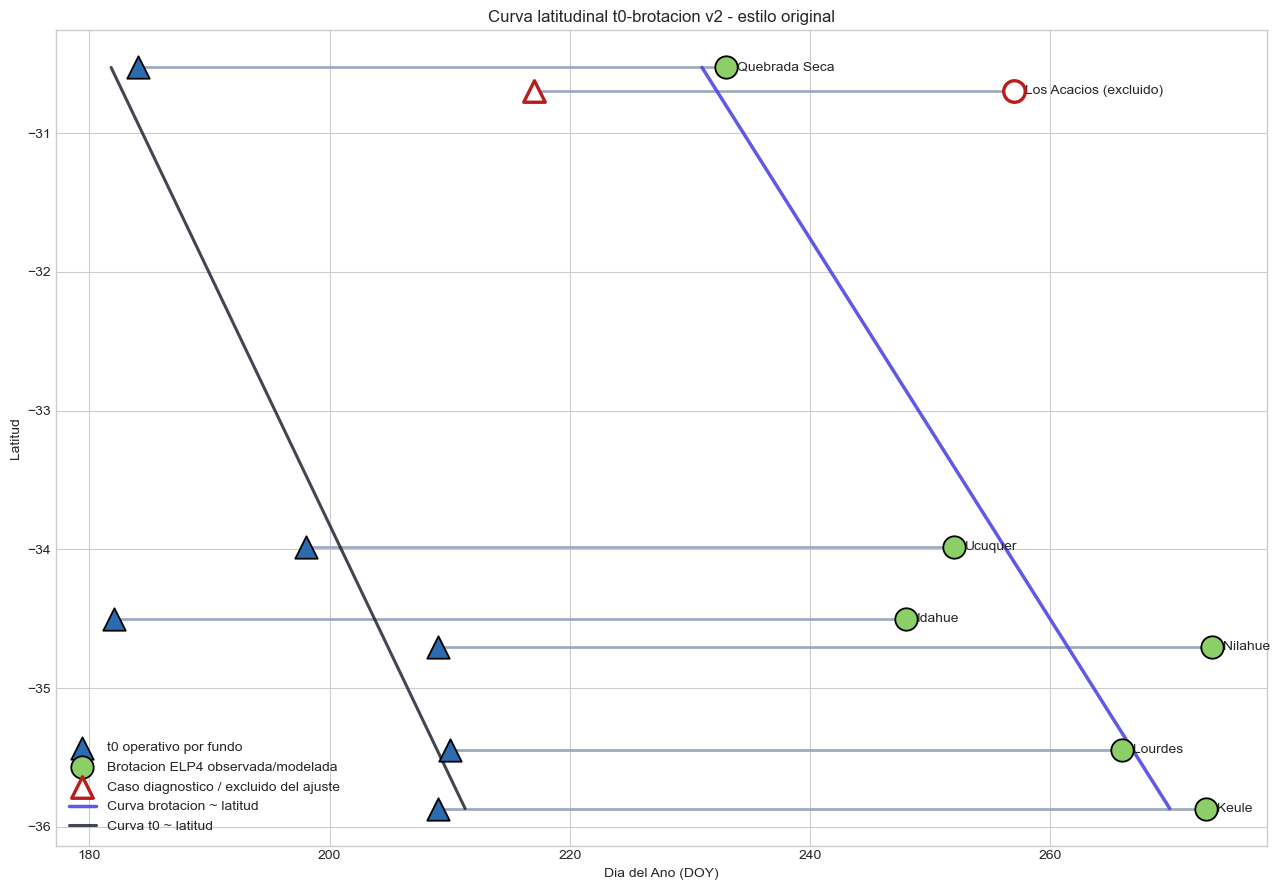

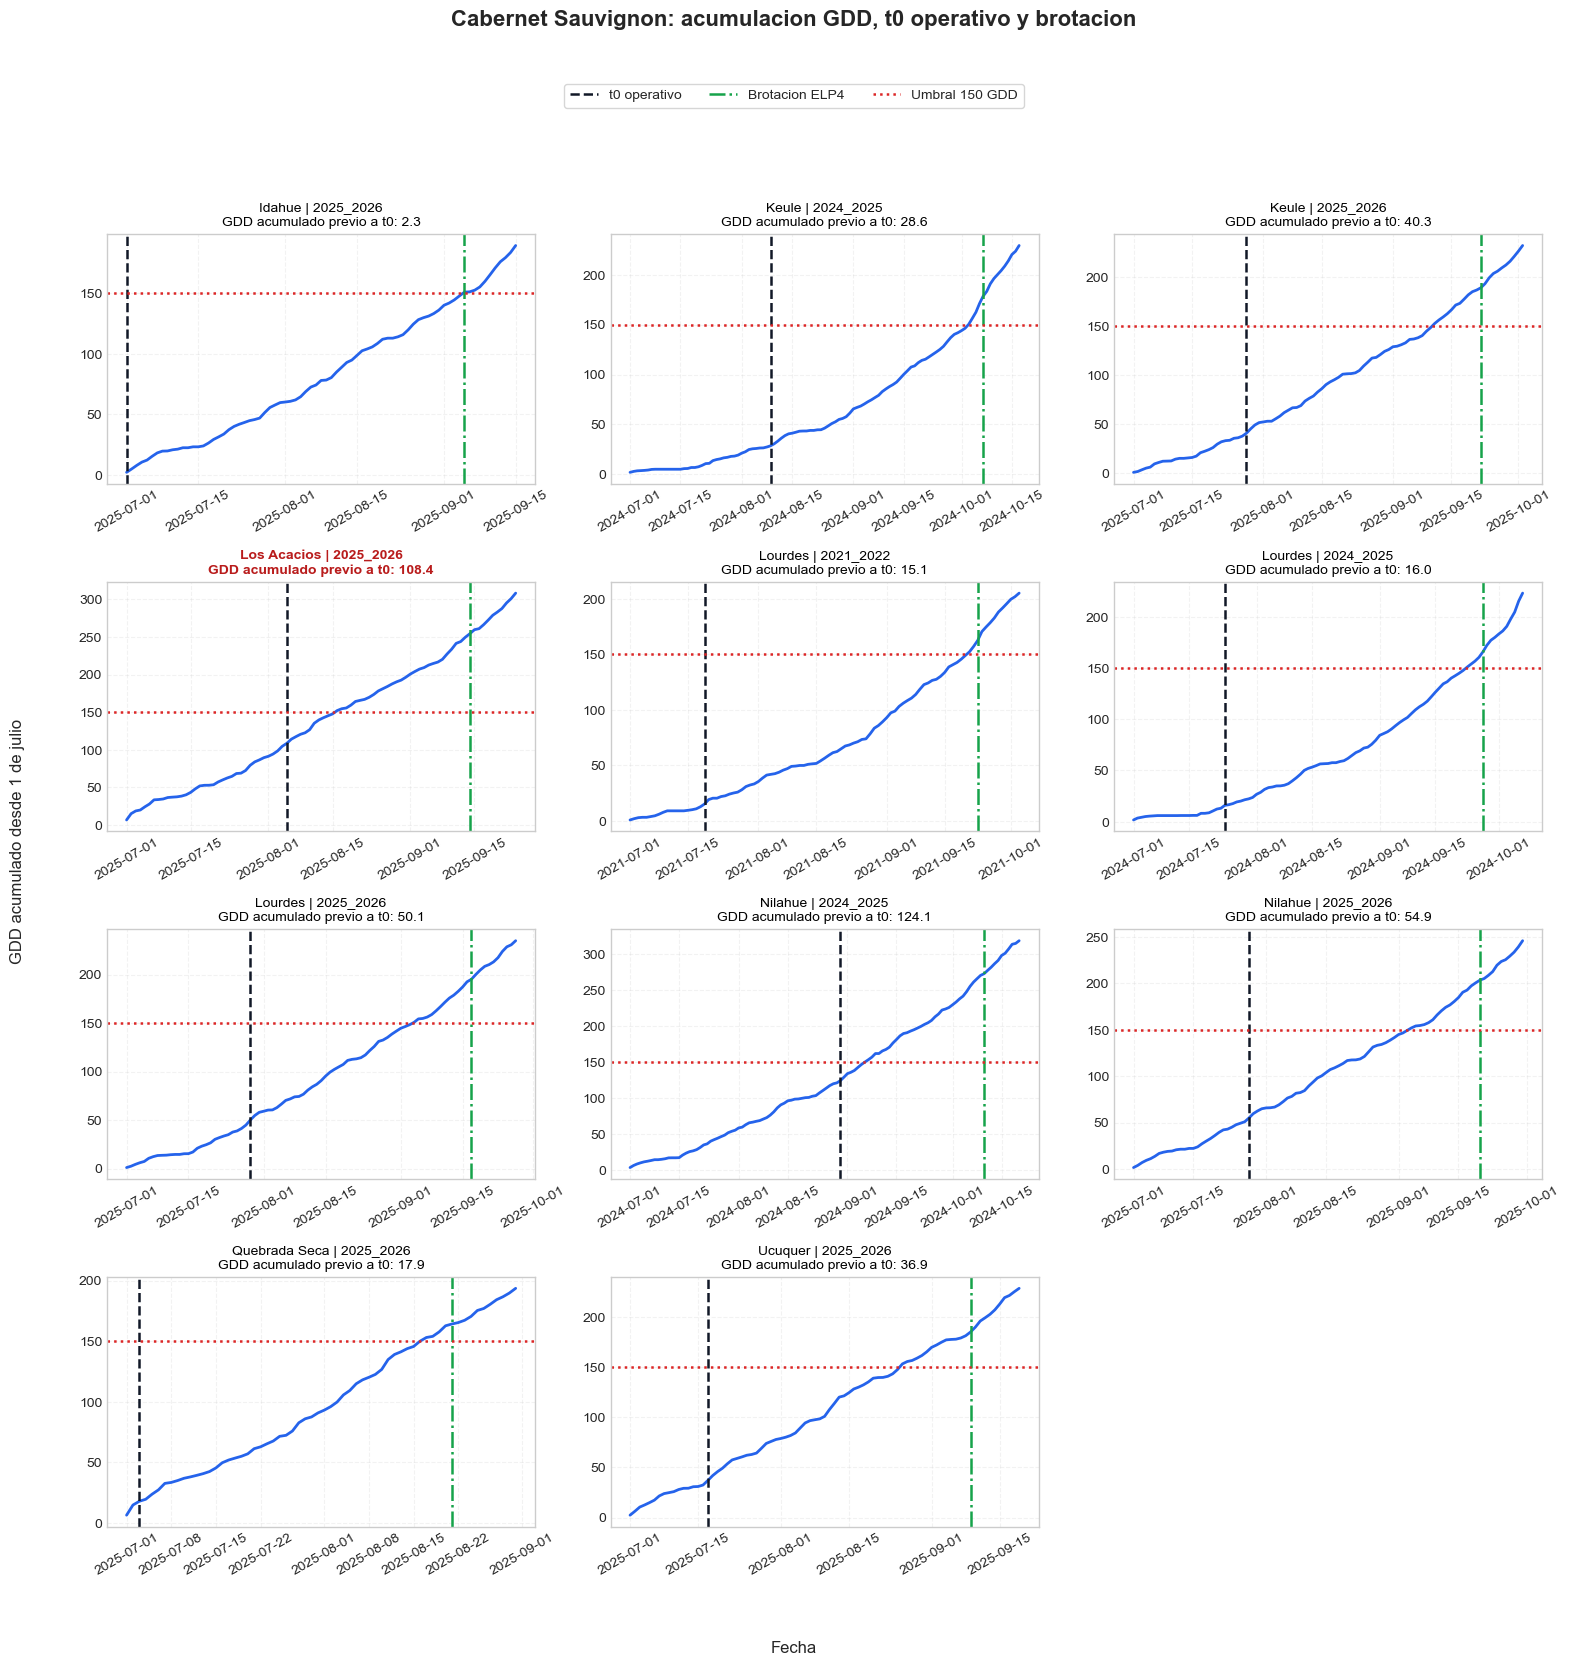

La regresion latitudinal se entrega como diagnostico/fallback. Con este R2 no se recomienda como predictor principal; se prioriza t0 por fundo.


In [11]:
brot_fit_source = (
    t0_by_case.groupby("fundo", dropna=False)
    .agg(
        latitud=("latitud", "median"),
        Fundo=("Fundo", "first"),
        doy_brotacion_observada=("fecha_ELP4_final", lambda s: float(pd.Series(s).dt.dayofyear.median()) if pd.Series(s).notna().any() else np.nan),
        doy_t0_operativo=("doy_t0", "median"),
        n_casos=("temporada", "size"),
        n_baja_confianza=("confianza_t0", lambda s: int((pd.Series(s) == "baja").sum())),
    )
    .reset_index()
)
brot_fit_source["incluido_en_regresion"] = (
    brot_fit_source["doy_t0_operativo"].notna() &
    brot_fit_source["doy_brotacion_observada"].notna() &
    ~brot_fit_source["fundo"].isin(REGRESSION_EXCLUDED_FUNDS)
)
brot_fit_source["motivo_exclusion"] = np.where(
    brot_fit_source["fundo"].isin(REGRESSION_EXCLUDED_FUNDS),
    "Excluido por instruccion metodologica / caso outlier para curva espacial",
    np.where(brot_fit_source["incluido_en_regresion"], "", "Sin datos suficientes para ajuste"),
)
brot_fit_source["incluir_en_ajuste"] = brot_fit_source["incluido_en_regresion"]
fit_mask = brot_fit_source["incluir_en_ajuste"]
brot_fit_source, diag_brot = fit_subset_predict_all(
    brot_fit_source, fit_mask, "latitud", "doy_brotacion_observada",
    "doy_brotacion_pred_regresion", "residuo_brotacion"
)
brot_fit_source, diag_t0 = fit_subset_predict_all(
    brot_fit_source, fit_mask, "latitud", "doy_t0_operativo",
    "doy_t0_predicho_regresion", "residuo_t0"
)

tabla_regresion_latitudinal_t0 = pd.DataFrame({
    "fundo": LOCAL_FUNDS,
    "Fundo": [FUNDO_DISPLAY.get(f, f) for f in LOCAL_FUNDS],
    "latitud": [FUNDO_LAT.get(f, np.nan) for f in LOCAL_FUNDS],
}).merge(
    t0_inicio_conteo_por_fundo[["fundo", "t0_operativo", "doy_t0_operativo", "confianza_t0"]],
    on="fundo",
    how="left",
).merge(
    brot_fit_source[["fundo", "doy_brotacion_observada", "doy_t0_predicho_regresion"]],
    on="fundo",
    how="left",
)
tabla_regresion_latitudinal_t0["t0_predicho_regresion"] = tabla_regresion_latitudinal_t0.apply(
    lambda r: date_from_season_doy(CURRENT_SEASON, r["doy_t0_predicho_regresion"]) if pd.notna(r["doy_t0_predicho_regresion"]) else pd.NaT,
    axis=1,
)
tabla_regresion_latitudinal_t0["residuo_dias"] = tabla_regresion_latitudinal_t0["doy_t0_operativo"] - tabla_regresion_latitudinal_t0["doy_t0_predicho_regresion"]
tabla_regresion_latitudinal_t0["usar_regresion_como"] = tabla_regresion_latitudinal_t0.apply(
    lambda r: "fallback" if pd.isna(r["t0_operativo"]) and pd.notna(r["t0_predicho_regresion"]) else ("referencia" if pd.notna(r["t0_operativo"]) else "no_recomendado"),
    axis=1,
)

t0_inicio_conteo_por_fundo = t0_inicio_conteo_por_fundo.merge(
    tabla_regresion_latitudinal_t0[["fundo", "t0_predicho_regresion", "doy_t0_predicho_regresion", "residuo_dias", "usar_regresion_como"]],
    on="fundo",
    how="left",
)
t0_inicio_conteo_por_fundo["t0_regresion_latitudinal"] = t0_inicio_conteo_por_fundo["t0_predicho_regresion"]
t0_inicio_conteo_por_fundo["doy_t0_regresion_latitudinal"] = t0_inicio_conteo_por_fundo["doy_t0_predicho_regresion"]
t0_inicio_conteo_por_fundo["usar_como"] = t0_inicio_conteo_por_fundo["usar_regresion_como"]

fundos_regresion_incluidos = ", ".join(sorted(brot_fit_source.loc[fit_mask, "fundo"].astype(str).unique()))
fundos_regresion_excluidos = ", ".join(sorted(brot_fit_source.loc[~fit_mask, "fundo"].astype(str).unique()))
latitudinal_diag = pd.DataFrame([
    {"relacion": "DOY_brotacion_observada ~ latitud", **diag_brot, "fundos_incluidos": fundos_regresion_incluidos, "fundos_excluidos": fundos_regresion_excluidos},
    {"relacion": "DOY_t0_operativo ~ latitud", **diag_t0, "fundos_incluidos": fundos_regresion_incluidos, "fundos_excluidos": fundos_regresion_excluidos},
])
display(latitudinal_diag)
display(tabla_regresion_latitudinal_t0.sort_values("latitud", ascending=False))

plot_df = tabla_regresion_latitudinal_t0.sort_values("latitud", ascending=False).copy()
style_df = plot_df.merge(
    brot_fit_source[["fundo", "doy_brotacion_pred_regresion", "incluir_en_ajuste", "motivo_exclusion"]],
    on="fundo",
    how="left",
)
style_df["caso_diagnostico"] = ~style_df["incluir_en_ajuste"].fillna(False)
style_df["es_los_acacios"] = style_df["fundo"].eq("los_acacios")

fig, ax = plt.subplots(figsize=(13, 9))
for _, row in style_df.iterrows():
    if pd.notna(row["doy_t0_operativo"]) and pd.notna(row["doy_brotacion_observada"]):
        ax.plot(
            [row["doy_t0_operativo"], row["doy_brotacion_observada"]],
            [row["latitud"], row["latitud"]],
            color="#94a3b8",
            linewidth=2.0,
            alpha=0.9,
            zorder=1,
        )
included = style_df[~style_df["caso_diagnostico"]].copy()
diagnostic = style_df[style_df["caso_diagnostico"]].copy()

if not included.empty:
    ax.scatter(
        included["doy_t0_operativo"], included["latitud"],
        marker="^", s=260, c="#2b6cb0", edgecolor="black", linewidth=1.3,
        label="t0 operativo por fundo", zorder=4,
    )
    ax.scatter(
        included["doy_brotacion_observada"], included["latitud"],
        marker="o", s=260, c="#8ccf68", edgecolor="black", linewidth=1.3,
        label="Brotacion ELP4 observada/modelada", zorder=5,
    )
if not diagnostic.empty:
    ax.scatter(
        diagnostic["doy_t0_operativo"], diagnostic["latitud"],
        marker="^", s=240, facecolor="white", edgecolor="#b91c1c", linewidth=2.4,
        label="Caso diagnostico / excluido del ajuste", zorder=4,
    )
    ax.scatter(
        diagnostic["doy_brotacion_observada"], diagnostic["latitud"],
        marker="o", s=240, facecolor="white", edgecolor="#b91c1c", linewidth=2.4,
        zorder=5,
    )
reg_line = style_df.dropna(subset=["latitud", "doy_brotacion_pred_regresion"]).sort_values("latitud", ascending=False)
if not reg_line.empty:
    ax.plot(
        reg_line["doy_brotacion_pred_regresion"], reg_line["latitud"],
        color="#4f46e5", linewidth=2.5, alpha=0.9,
        label="Curva brotacion ~ latitud", zorder=2,
    )
reg_t0 = style_df.dropna(subset=["latitud", "doy_t0_predicho_regresion"]).sort_values("latitud", ascending=False)
if not reg_t0.empty:
    ax.plot(
        reg_t0["doy_t0_predicho_regresion"], reg_t0["latitud"],
        color="#111827", linewidth=2.2, alpha=0.8,
        label="Curva t0 ~ latitud", zorder=2,
    )
for _, row in style_df.iterrows():
    x_ref = row["doy_brotacion_observada"] if pd.notna(row["doy_brotacion_observada"]) else row["doy_t0_operativo"]
    if pd.notna(x_ref):
        label_fundo = row["Fundo"] + (" (excluido)" if row["fundo"] == "los_acacios" else "")
        ax.annotate(label_fundo, xy=(x_ref, row["latitud"]), xytext=(8, 0), textcoords="offset points", fontsize=10, va="center")
ax.set_title("Curva latitudinal t0-brotacion v2 - estilo original")
ax.set_xlabel("Dia del Ano (DOY)")
ax.set_ylabel("Latitud")
ax.legend(loc="lower left")
plt.tight_layout()
fig_lat_style = savefig_report("curva_latitudinal_t0_brotacion_indicador_biologico.png")
plt.show()



# Paneles de acumulacion termica Cabernet para revisar posicion metodologica de t0.
panel_cases = t0_by_case[
    t0_by_case["t0_estimado"].notna() &
    t0_by_case["fecha_ELP4_final"].notna()
].copy().sort_values(["fundo", "temporada"])

n_panels = len(panel_cases)
ncols = 3
nrows = int(np.ceil(n_panels / ncols)) if n_panels else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows), sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax_panel, rec in zip(axes, panel_cases.itertuples(index=False)):
    qa_match = audit_df[
        (audit_df["fundo"] == rec.fundo) &
        (audit_df["variedad"] == rec.variedad_indicadora) &
        (audit_df["temporada"] == rec.temporada)
    ]
    if qa_match.empty:
        ax_panel.set_visible(False)
        continue
    daily = series_map.get(qa_match.iloc[0]["archivo_limpio"])
    if daily is None or daily.empty:
        ax_panel.set_visible(False)
        continue
    season_start = season_biofix(rec.temporada, 7, 1)
    season_end = pd.Timestamp(rec.fecha_ELP4_final) + pd.Timedelta(days=10)
    curve = daily[(daily["Fecha"] >= season_start) & (daily["Fecha"] <= season_end)].copy()
    curve = add_gdd(curve)
    curve["gdd_acum_desde_1julio"] = curve["gdd_diario"].fillna(0).cumsum()

    ax_panel.plot(curve["Fecha"], curve["gdd_acum_desde_1julio"], color="#2563eb", linewidth=2)
    ax_panel.axvline(pd.Timestamp(rec.t0_estimado), color="#111827", linestyle="--", linewidth=1.8, label="t0 operativo")
    ax_panel.axvline(pd.Timestamp(rec.fecha_ELP4_final), color="#16a34a", linestyle="-.", linewidth=1.8, label="Brotacion ELP4")
    ax_panel.axhline(rec.threshold_GDD_usado, color="#dc2626", linestyle=":", linewidth=1.8, label=f"Umbral {rec.threshold_GDD_usado:.0f} GDD")
    gdd_at_t0 = curve.loc[curve["Fecha"] <= pd.Timestamp(rec.t0_estimado), "gdd_acum_desde_1julio"]
    gdd_t0_value = float(gdd_at_t0.iloc[-1]) if not gdd_at_t0.empty else np.nan
    title_color = "#b91c1c" if rec.fundo == "los_acacios" else "black"
    ax_panel.set_title(
        f"{FUNDO_DISPLAY.get(rec.fundo, rec.fundo)} | {rec.temporada}\n"
        f"GDD acumulado previo a t0: {gdd_t0_value:.1f}",
        fontsize=10,
        color=title_color,
        fontweight="bold" if rec.fundo == "los_acacios" else "normal",
    )
    ax_panel.grid(True, alpha=0.25, linestyle="--")
    ax_panel.tick_params(axis="x", rotation=30)

for ax_panel in axes[n_panels:]:
    ax_panel.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels() if n_panels else ([], [])
if handles:
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=3, frameon=True)
fig.suptitle("Cabernet Sauvignon: acumulacion GDD, t0 operativo y brotacion", fontsize=16, fontweight="bold", y=0.995)
fig.supxlabel("Fecha", y=0.015)
fig.supylabel("GDD acumulado desde 1 de julio", x=0.01)
plt.tight_layout(rect=[0.025, 0.035, 0.99, 0.91])
fig_panel_gdd = savefig_report("cs_paneles_gda_temporada_t0_brotacion.png")
plt.show()

if pd.notna(diag_t0["r2"]) and diag_t0["r2"] < 0.40:
    print("La regresion latitudinal se entrega como diagnostico/fallback. Con este R2 no se recomienda como predictor principal; se prioriza t0 por fundo.")

pred_rows = []
for rec in audit_df.itertuples(index=False):
    lat = FUNDO_LAT.get(rec.fundo, np.nan)
    doy_pred = np.nan
    fecha_pred = pd.NaT
    if pd.notna(lat) and pd.notna(diag_brot.get("pendiente", np.nan)) and pd.notna(diag_brot.get("intercepto", np.nan)):
        doy_pred = diag_brot["intercepto"] + diag_brot["pendiente"] * lat
        fecha_pred = date_from_season_doy(rec.temporada, doy_pred)
    doy_obs = rec.fecha_ELP4_final.dayofyear if pd.notna(rec.fecha_ELP4_final) else np.nan
    pred_rows.append({
        "fundo": rec.fundo,
        "variedad": rec.variedad,
        "lat": lat,
        "temporada": rec.temporada,
        "doy_brotacion_observado": doy_obs,
        "fecha_brotacion_observada": rec.fecha_ELP4_final,
        "doy_brotacion_predicho_curva": doy_pred,
        "fecha_brotacion_predicha_curva": fecha_pred,
        "diferencia_dias_observado_predicho": doy_pred - doy_obs if pd.notna(doy_obs) and pd.notna(doy_pred) else np.nan,
        "fuente_prediccion": "curva_latitudinal_v2",
        "observacion": "Comparacion exploratoria entre brotacion observada/modelada y curva espacial v2.",
    })

prediccion_brotacion_por_curva_latitudinal = pd.DataFrame(pred_rows)
resumen_variedades_vs_curva_latitudinal = (
    prediccion_brotacion_por_curva_latitudinal.groupby("variedad", dropna=False)
    .agg(
        n_observaciones=("temporada", "size"),
        diferencia_media_dias=("diferencia_dias_observado_predicho", "mean"),
        diferencia_std_dias=("diferencia_dias_observado_predicho", lambda s: float(pd.Series(s).std(ddof=1)) if pd.Series(s).notna().sum() > 1 else 0.0),
        mae_dias=("diferencia_dias_observado_predicho", lambda s: float(pd.Series(s).dropna().abs().mean()) if pd.Series(s).notna().any() else np.nan),
        sesgo_promedio_dias=("diferencia_dias_observado_predicho", "mean"),
        tiene_repeticion_varietal=("temporada", lambda s: bool(pd.Series(s).nunique() >= 2)),
    )
    .reset_index()
)
resumen_variedades_vs_curva_latitudinal["interpretacion"] = (
    "Comparacion exploratoria. La curva latitudinal no reemplaza un modelo varietal propio."
)

## 10.1 Vista rapida de figuras dentro del notebook

Estas figuras tambien quedan exportadas en `reports/phenology/indicador_biologico/`, pero se insertan aqui para que la lectura metodologica quede contenida en el notebook.

### Curva latitudinal t0-brotacion

![Curva latitudinal t0-brotacion](figures/curva_latitudinal_t0_brotacion_indicador_biologico.png)

### Paneles de acumulacion termica Cabernet

![Paneles GDD t0 brotacion](figures/cs_paneles_gda_temporada_t0_brotacion.png)


## 9. GDD resultante por variedad usando t0 por fundo

In [12]:
t0_lookup = t0_inicio_conteo_por_fundo[[
    "fundo", "t0_operativo", "t0_mes_operativo", "t0_dia_operativo",
    "t0_regresion_latitudinal", "tipo_t0", "confianza_t0", "usar_como"
]].copy()
t0_lookup["tipo_t0_usado"] = np.where(
    t0_lookup["t0_operativo"].notna(),
    "t0_operativo_por_fundo",
    np.where(t0_lookup["t0_regresion_latitudinal"].notna(), "t0_regresion_latitudinal_fallback", "sin_t0"),
)

gdd_var_rows = []
for rec in audit_df.itertuples(index=False):
    daily = series_map.get(rec.archivo_limpio)
    t0_row = t0_lookup[t0_lookup["fundo"] == rec.fundo]
    if not t0_row.empty and pd.notna(t0_row["t0_mes_operativo"].iloc[0]) and pd.notna(t0_row["t0_dia_operativo"].iloc[0]):
        t0_usado = season_biofix(rec.temporada, int(t0_row["t0_mes_operativo"].iloc[0]), int(t0_row["t0_dia_operativo"].iloc[0]))
    elif not t0_row.empty and pd.notna(t0_row["t0_regresion_latitudinal"].iloc[0]):
        reg_ts = pd.Timestamp(t0_row["t0_regresion_latitudinal"].iloc[0])
        t0_usado = season_biofix(rec.temporada, int(reg_ts.month), int(reg_ts.day))
    else:
        t0_usado = pd.NaT
    tipo_t0_usado = t0_row["tipo_t0_usado"].iloc[0] if not t0_row.empty else "sin_t0"
    alerta = ""
    gdd_val = np.nan
    if pd.isna(rec.fecha_ELP4_final):
        alerta = "sin_fecha_ELP4_final"
    elif pd.isna(t0_usado):
        alerta = "sin_t0_disponible"
    elif daily is None or daily.empty:
        alerta = "sin_clima_suficiente_para_calcular_GDD"
    elif rec.fecha_ELP4_final < t0_usado:
        alerta = "fecha_ELP4_antes_de_t0"
    else:
        gdd_val = accumulated_gdd(daily, pd.Timestamp(t0_usado), rec.fecha_ELP4_final)
        if pd.notna(gdd_val) and float(gdd_val) == 0.0:
            alerta = "GDD_brotacion_igual_cero"
        elif str(rec.tipo_ELP4_final) == "modelado_sin_observacion_cercana":
            alerta = "ELP4_modelado_sin_observacion_cercana"
    gdd_var_rows.append({
        "fundo": rec.fundo,
        "variedad": rec.variedad,
        "temporada": rec.temporada,
        "biofix_usado": rec.biofix_label,
        "fecha_ELP4_final": rec.fecha_ELP4_final,
        "tipo_ELP4_final": rec.tipo_ELP4_final,
        "t0_usado": t0_usado,
        "tipo_t0_usado": tipo_t0_usado,
        "threshold_GDD_indicador": GDD_REF_V2_FIXED,
        "gdd_desde_t0_hasta_ELP4": gdd_val,
        "alerta": alerta,
    })

gdd_por_variedad_usando_t0_fundo = pd.DataFrame(gdd_var_rows).sort_values(["fundo", "variedad", "temporada"]).reset_index(drop=True)
gdd_summary_by_variety = (
    gdd_por_variedad_usando_t0_fundo.groupby("variedad", dropna=False)
    .agg(
        n_casos=("temporada", "size"),
        gdd_promedio=("gdd_desde_t0_hasta_ELP4", "mean"),
        gdd_mediana=("gdd_desde_t0_hasta_ELP4", "median"),
        gdd_std=("gdd_desde_t0_hasta_ELP4", lambda s: float(np.std(s.dropna(), ddof=1)) if s.dropna().shape[0] > 1 else 0.0),
        gdd_min=("gdd_desde_t0_hasta_ELP4", "min"),
        gdd_max=("gdd_desde_t0_hasta_ELP4", "max"),
        n_observados=("tipo_ELP4_final", lambda s: int((s == "observado").sum())),
        n_interpolados=("tipo_ELP4_final", lambda s: int((s == "interpolado_cercano").sum())),
        n_modelados=("tipo_ELP4_final", lambda s: int(s.astype(str).str.startswith("modelado").sum())),
        n_alertas=("alerta", lambda s: int((s != "").sum())),
    )
    .reset_index()
)
gdd_summary_by_variety["interpretacion"] = gdd_summary_by_variety.apply(
    lambda r: (
        "Requerimiento relativamente estable bajo t0 por fundo."
        if pd.notna(r["gdd_std"]) and r["gdd_std"] <= 15 and r["n_alertas"] == 0
        else "Resultado util como referencia, pero con dispersion o alertas que obligan lectura prudente."
    ),
    axis=1,
)
display(gdd_por_variedad_usando_t0_fundo.head(20))
display(gdd_summary_by_variety)

delta_keule_lookup = (
    regla_delta_varietal[regla_delta_varietal["flujo"].eq("alternativo_keule_cs_150")]
    [["variedad", "n_temporadas_validas", "delta_aplicado", "delta_gdd", "gdd_referencia_ajustada", "motivo_delta"]]
    .rename(columns={"gdd_referencia_ajustada": "gdd_referencia_ajustada_delta"})
)
gdd_summary_by_variety = gdd_summary_by_variety.merge(delta_keule_lookup, on="variedad", how="left")
display(gdd_summary_by_variety[[
    "variedad", "n_temporadas_validas", "delta_aplicado", "delta_gdd",
    "gdd_referencia_ajustada_delta", "motivo_delta",
]])

,fundo,variedad,temporada,biofix_usado,fecha_ELP4_final,tipo_ELP4_final,t0_usado,tipo_t0_usado,threshold_GDD_indicador,gdd_desde_t0_hasta_ELP4,alerta
0,idahue,cabernet_sauvignon,2025_2026,1-agosto,2025-09-05,observado,2025-07-01,t0_operativo_por_fundo,150,150.741473,
1,idahue,carmenere,2025_2026,1-agosto,2025-09-19,observado,2025-07-01,t0_operativo_por_fundo,150,207.477970,
2,idahue,chardonnay,2025_2026,1-agosto,2025-09-19,observado,2025-07-01,t0_operativo_por_fundo,150,207.477970,
3,idahue,sauvignon_blanc,2025_2026,1-agosto,2025-09-17,observado,2025-07-01,t0_operativo_por_fundo,150,197.288077,
4,keule,cabernet_sauvignon,2024_2025,1-agosto,2024-10-07,observado,2024-07-28,t0_operativo_por_fundo,150,161.890460,
5,keule,cabernet_sauvignon,2025_2026,1-agosto,2025-09-22,observado,2025-07-28,t0_operativo_por_fundo,150,151.365924,
6,keule,carmenere,2025_2026,1-agosto,2025-09-14,observado,2025-07-28,t0_operativo_por_fundo,150,124.960229,
7,keule,chardonnay,2025_2026,1-agosto,2025-08-26,observado,2025-07-28,t0_operativo_por_fundo,150,75.507198,
8,keule,sauvignon_blanc,2025_2026,1-agosto,2025-09-07,observado,2025-07-28,t0_operativo_por_fundo,150,100.423546,
9,los_acacios,cabernet_sauvignon,2025_2026,1-agosto,2025-09-14,observado,2025-08-05,t0_operativo_por_fundo,150,149.907129,


,variedad,n_casos,gdd_promedio,gdd_mediana,gdd_std,gdd_min,gdd_max,n_observados,n_interpolados,n_modelados,n_alertas,interpretacion
0,cabernet_sauvignon,11,156.789012,150.741473,23.784466,134.835613,225.889820,10,0,1,1,"Resultado util como referencia, pero con dispe..."
1,carmenere,7,133.754607,122.998636,39.130329,96.179951,207.477970,7,0,0,0,"Resultado util como referencia, pero con dispe..."
2,chardonnay,10,121.604633,106.274880,46.185014,75.507198,207.477970,8,0,0,2,"Resultado util como referencia, pero con dispe..."
3,sauvignon_blanc,8,139.195899,125.040787,36.489028,100.423546,197.288077,8,0,0,0,"Resultado util como referencia, pero con dispe..."


,variedad,n_temporadas_validas,delta_aplicado,delta_gdd,gdd_referencia_ajustada_delta,motivo_delta
0,cabernet_sauvignon,2,False,0.000000,148.354922,No aplicado: la variedad tiene dos o mas tempo...
1,carmenere,1,True,10.787183,116.555636,Aplicado: existe exactamente una temporada val...
2,chardonnay,1,True,10.787183,67.102604,Aplicado: existe exactamente una temporada val...
3,sauvignon_blanc,1,True,10.787183,92.018952,Aplicado: existe exactamente una temporada val...


## 13. Resumen ejecutivo v2

In [13]:
final_alert_rows = []
for _, rec in audit_df.iterrows():
    base_alerts = initial_alerts_df[
        (initial_alerts_df["fundo"] == rec["fundo"]) &
        (initial_alerts_df["variedad"] == rec["variedad"]) &
        (initial_alerts_df["temporada"] == rec["temporada"])
    ].copy()
    final_alert_rows.extend(base_alerts.to_dict("records"))

for _, rec in t0_by_case.iterrows():
    if bool(rec["fecha_ELP4_antes_de_t0"]):
        final_alert_rows.append({
            "fundo": rec["fundo"],
            "variedad": rec["variedad_indicadora"],
            "temporada": rec["temporada"],
            "fecha_ELP4_final": rec["fecha_ELP4_final"],
            "tipo_ELP4_final": rec["tipo_ELP4_final"],
            "biofix_usado": rec["biofix_usado"],
            "t0_estimado": rec["t0_estimado"],
            "threshold_GDD_usado": rec["threshold_GDD_usado"],
            "gdd_a_brotacion": np.nan,
            "alerta": "fecha_ELP4_antes_de_t0",
            "diagnostico_probable": "La reconstruccion del t0 queda despues de la brotacion observada/modelada.",
            "accion_recomendada": "No usar este caso para fijar el ancla; revisar biofix, ELP4 o temporada.",
        })

for _, rec in gdd_por_variedad_usando_t0_fundo.iterrows():
    if str(rec.get("alerta", "")).strip() == "":
        continue
    diagnostico = {
        "fecha_ELP4_antes_de_t0": "La fecha ELP4 de ese caso queda antes del t0 operativo usado para el fundo.",
        "sin_fecha_ELP4_final": "No existe una fecha final de ELP4 para calcular GDD desde t0.",
    }.get(str(rec["alerta"]), "Caso con alerta metodologica en el calculo de GDD desde t0.")
    accion = {
        "fecha_ELP4_antes_de_t0": "Mantener el caso como diagnostico; no usarlo para cerrar un requerimiento termico estable.",
        "sin_fecha_ELP4_final": "No usar el caso en comparaciones termicas hasta completar la trazabilidad de ELP4.",
    }.get(str(rec["alerta"]), "Revisar trazabilidad del caso antes de usarlo como evidencia principal.")
    final_alert_rows.append({
        "fundo": rec["fundo"],
        "variedad": rec["variedad"],
        "temporada": rec["temporada"],
        "fecha_ELP4_final": rec["fecha_ELP4_final"],
        "tipo_ELP4_final": rec["tipo_ELP4_final"],
        "biofix_usado": rec["biofix_usado"],
        "t0_estimado": rec["t0_usado"],
        "threshold_GDD_usado": rec["threshold_GDD_indicador"],
        "gdd_a_brotacion": rec["gdd_desde_t0_hasta_ELP4"],
        "alerta": rec["alerta"],
        "diagnostico_probable": diagnostico,
        "accion_recomendada": accion,
    })

v2_alertas_inconsistencias_fenologicas = pd.DataFrame(final_alert_rows)
if v2_alertas_inconsistencias_fenologicas.empty:
    v2_alertas_inconsistencias_fenologicas = pd.DataFrame(columns=[
        "fundo","variedad","temporada","fecha_ELP4_final","tipo_ELP4_final","biofix_usado","t0_estimado",
        "threshold_GDD_usado","gdd_a_brotacion","alerta","diagnostico_probable","accion_recomendada"
    ])

auditoria_gdd_indicador_biologico = pd.DataFrame([
    {
        "columna": "gdd_acumulado",
        "archivo_origen": "reports/phenology/elp4_cleaning_report.csv",
        "script_origen": "src/processing/build_phenology_consolidate.py",
        "metodo": "operativo_antiguo",
        "uso_recomendado": "no_usar_como_GDD_fenologico_principal",
        "comentario": "Acumulado operativo historico; no usar como referencia principal del indicador biologico.",
    },
    {
        "columna": "GDD_acum",
        "archivo_origen": "data/prepared/phenology/consolidado_fenologia_multitemporada_CORREGIDO_GDD_SENO_SIMPLE.xlsx",
        "script_origen": "src/processing/build_phenology_gdd_sine_correction.py",
        "metodo": "acumulado_simple_o_heredado",
        "uso_recomendado": "no_usar_como_GDD_fenologico_principal",
        "comentario": "Puede existir por trazabilidad historica, pero no reemplaza el GDD por seno simple del indicador.",
    },
    {
        "columna": "gdd_a_brotacion",
        "archivo_origen": "reports/phenology/indicador_biologico/evaluacion_biofix_candidatos.xlsx",
        "script_origen": "models/indicador_biologico/multisite_multivariety_gdd_analysis_v2_t0_latitudinal.ipynb",
        "metodo": "seno_simple",
        "uso_recomendado": "usar",
        "comentario": "GDD acumulado desde biofix candidato hasta ELP4 usando seno simple.",
    },
    {
        "columna": "gdd_desde_t0_hasta_ELP4",
        "archivo_origen": "reports/phenology/indicador_biologico/gdd_por_variedad_usando_t0_fundo.xlsx",
        "script_origen": "models/indicador_biologico/multisite_multivariety_gdd_analysis_v2_t0_latitudinal.ipynb",
        "metodo": "seno_simple",
        "uso_recomendado": "usar",
        "comentario": "Requerimiento termico desde t0 operativo por fundo hasta ELP4.",
    },
    {
        "columna": "threshold_GDD_usado",
        "archivo_origen": "reports/phenology/indicador_biologico/umbral_indicador_biologico.xlsx",
        "script_origen": "models/indicador_biologico/multisite_multivariety_gdd_analysis_v2_t0_latitudinal.ipynb",
        "metodo": "seno_simple",
        "uso_recomendado": "usar",
        "comentario": "Umbral redondeado a 0 o 5 adoptado para el indicador biologico.",
    },
])

audit_path = REPORT_BIO_DIR / "auditoria_elp4_fundo_variedad_temporada.xlsx"
gdd_audit_path = REPORT_BIO_DIR / "auditoria_gdd_indicador_biologico.xlsx"
biofix_eval_path = REPORT_BIO_DIR / "evaluacion_biofix_candidatos.xlsx"
alert_path = REPORT_BIO_DIR / "alertas_inconsistencias_fenologicas.xlsx"
ranking_path = REPORT_BIO_DIR / "ranking_indicador_biologico.xlsx"
threshold_path = REPORT_BIO_DIR / "umbral_indicador_biologico.xlsx"
t0_path = REPORT_BIO_DIR / "t0_inicio_conteo_por_fundo.xlsx"
gdd_var_path = REPORT_BIO_DIR / "gdd_por_variedad_usando_t0_fundo.xlsx"
reg_lat_path = REPORT_BIO_DIR / "tabla_regresion_latitudinal_t0.xlsx"
pred_curve_path = REPORT_BIO_DIR / "prediccion_brotacion_por_curva_latitudinal.xlsx"
resumen_curve_path = REPORT_BIO_DIR / "resumen_variedades_vs_curva_latitudinal.xlsx"
readme_path = REPORT_BIO_DIR / "README_indicador_biologico_metodologico.md"

with pd.ExcelWriter(audit_path) as writer:
    audit_df.to_excel(writer, sheet_name="auditoria_elp4", index=False)
    pheno_model_summary.to_excel(writer, sheet_name="pheno_modeling_apoyo", index=False)
    audit_df[audit_df["tipo_ELP4_final"].eq("no_evaluable")].to_excel(writer, sheet_name="casos_no_evaluables", index=False)
    audit_df.groupby("tipo_ELP4_final").size().reset_index(name="n_casos").to_excel(writer, sheet_name="resumen_tipos", index=False)

auditoria_gdd_indicador_biologico.to_excel(gdd_audit_path, index=False)

with pd.ExcelWriter(biofix_eval_path) as writer:
    biofix_summary_df.to_excel(writer, sheet_name="resumen_biofix", index=False)
    biofix_detail_df.to_excel(writer, sheet_name="detalle_por_caso", index=False)

with pd.ExcelWriter(alert_path) as writer:
    v2_alertas_inconsistencias_fenologicas.to_excel(writer, sheet_name="alertas", index=False)
    (v2_alertas_inconsistencias_fenologicas.groupby("alerta").size().reset_index(name="n_casos")
     if not v2_alertas_inconsistencias_fenologicas.empty else pd.DataFrame(columns=["alerta", "n_casos"])
    ).to_excel(writer, sheet_name="resumen", index=False)

with pd.ExcelWriter(ranking_path) as writer:
    candidate_rank_alt.to_excel(writer, sheet_name="ranking", index=False)
    selected_indicator.to_frame().T.to_excel(writer, sheet_name="seleccionado", index=False)

with pd.ExcelWriter(threshold_path) as writer:
    anchor_detail.to_excel(writer, sheet_name="detalle_temporadas", index=False)
    threshold_eval.to_excel(writer, sheet_name="evaluacion_umbral", index=False)
    threshold_summary.to_excel(writer, sheet_name="resumen", index=False)
    regla_delta_varietal.to_excel(writer, sheet_name="regla_delta", index=False)

with pd.ExcelWriter(t0_path) as writer:
    t0_inicio_conteo_por_fundo.to_excel(writer, sheet_name="t0_por_fundo", index=False)
    t0_by_case.to_excel(writer, sheet_name="t0_por_caso_indicador", index=False)

with pd.ExcelWriter(gdd_var_path) as writer:
    gdd_por_variedad_usando_t0_fundo.to_excel(writer, sheet_name="detalle", index=False)
    gdd_summary_by_variety.to_excel(writer, sheet_name="resumen_variedad", index=False)

tabla_regresion_latitudinal_t0.to_excel(reg_lat_path, index=False)
prediccion_brotacion_por_curva_latitudinal.to_excel(pred_curve_path, index=False)
resumen_variedades_vs_curva_latitudinal.to_excel(resumen_curve_path, index=False)

readme_path.write_text(
    f"""# README - indicador biologico fenologico

## Indicador biologico seleccionado
- Fundo: `{INDICATOR_FUNDO_V2}`
- Variedad: `{INDICATOR_VARIETY_V2}`
- Biofix adoptado: `{BIOFIX_ADOPTADO_LABEL}`
- GDD promedio: `{threshold_summary.loc[0, 'gdd_promedio']:.3f}`
- GDD mediana: `{threshold_summary.loc[0, 'gdd_mediana']:.3f}`
- Umbral adoptado: `{GDD_REF_V2_FIXED}`
- Justificacion: `{criterion_text}`

## Lectura metodologica
- Los casos inconsistentes no se eliminan silenciosamente: quedan en `alertas_inconsistencias_fenologicas.xlsx`.
- `pheno_modeling-main` se usa solo como apoyo diagnostico. No decide el ancla biologica ni justifica imputaciones automaticas cuando el umbral queda fuera de rango.
- La regresion latitudinal se entrega como diagnostico/fallback. Si el `R2` es bajo, se prioriza `t0` por fundo.
- Este flujo queda aislado del trabajo de Luis, madurez tecnica, train/test y datasets de modelacion.

## Archivos clave
- `auditoria_elp4_fundo_variedad_temporada.xlsx`
- `auditoria_gdd_indicador_biologico.xlsx`
- `evaluacion_biofix_candidatos.xlsx`
- `ranking_indicador_biologico.xlsx`
- `umbral_indicador_biologico.xlsx`
- `t0_inicio_conteo_por_fundo.xlsx`
- `gdd_por_variedad_usando_t0_fundo.xlsx`
- `tabla_regresion_latitudinal_t0.xlsx`
- `prediccion_brotacion_por_curva_latitudinal.xlsx`
- `resumen_variedades_vs_curva_latitudinal.xlsx`
- `curva_latitudinal_t0_brotacion_indicador_biologico.png`
- `cs_paneles_gda_temporada_t0_brotacion.png`
""",
    encoding="utf-8",
)

resumen_alertas = (
    v2_alertas_inconsistencias_fenologicas.groupby("alerta").size().to_dict()
    if not v2_alertas_inconsistencias_fenologicas.empty else {}
)
uso_regresion = (
    "no_recomendado" if pd.isna(diag_t0["r2"]) else
    ("fallback" if diag_t0["r2"] < 0.40 else "referencia")
)
print("Indicador biologico seleccionado:")
print("Fundo:", INDICATOR_FUNDO_V2)
print("Variedad:", INDICATOR_VARIETY_V2)
print("Biofix adoptado:", BIOFIX_ADOPTADO_LABEL)
print("GDD promedio:", round(float(threshold_summary.loc[0, "gdd_promedio"]), 3))
print("GDD mediana:", round(float(threshold_summary.loc[0, "gdd_mediana"]), 3))
print("Umbral adoptado:", GDD_REF_V2_FIXED)
print("Justificacion:", criterion_text)
print("\nt0 recomendado por fundo:")
display(t0_inicio_conteo_por_fundo[["Fundo", "biofix_usado", "t0_operativo", "doy_t0_operativo", "confianza_t0", "criterio_t0", "usar_como"]])
print("\nGDD resultante por variedad:")
display(gdd_summary_by_variety)
print("\nRegresion latitudinal:")
display(latitudinal_diag)
print("R2 brotacion:", None if pd.isna(diag_brot["r2"]) else round(float(diag_brot["r2"]), 3))
print("R2 t0:", None if pd.isna(diag_t0["r2"]) else round(float(diag_t0["r2"]), 3))
print("uso recomendado:", uso_regresion)
print("\nComparacion variedades vs curva latitudinal:")
display(resumen_variedades_vs_curva_latitudinal)
print("\nAlertas metodologicas:")
print("n casos GDD=0:", resumen_alertas.get("GDD_brotacion_igual_cero", 0))
print("n casos ELP4 antes de biofix:", resumen_alertas.get("fecha_ELP4_antes_de_biofix", 0))
print("n casos ELP4 antes de t0:", resumen_alertas.get("fecha_ELP4_antes_de_t0", 0))
print("n casos modelados sin observacion cercana:", resumen_alertas.get("ELP4_modelado_sin_observacion_cercana", 0))
print("n series que parten tarde:", resumen_alertas.get("serie_fenologica_parte_tarde", 0))

meeting_master_path = ROOT / "reports" / "reunion_camilo_obj3" / "01_TABLA_MAESTRA_INDICADOR_BIOLOGICO.xlsx"
if meeting_master_path.exists():
    with pd.ExcelWriter(meeting_master_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        regla_delta_varietal.to_excel(writer, sheet_name="11_regla_delta", index=False)


Indicador biologico seleccionado:
Fundo: keule
Variedad: cabernet_sauvignon
Biofix adoptado: 1-agosto
GDD promedio: 148.355
GDD mediana: 148.355
Umbral adoptado: 150
Justificacion: Se adopta 150 GDD para el flujo alternativo Keule, con inicio fijo 1-agosto; el promedio observado es 148.355 GDD.

t0 recomendado por fundo:


,Fundo,biofix_usado,t0_operativo,doy_t0_operativo,confianza_t0,criterio_t0,usar_como
0,Quebrada Seca,1-agosto,2025-07-03,184,alta,temporada_actual_confiable,referencia
1,Los Acacios,1-agosto,2025-08-05,217,alta,temporada_actual_confiable,referencia
2,Ucuquer,1-agosto,2025-07-17,198,alta,temporada_actual_confiable,referencia
3,Idahue,1-agosto,2025-07-01,182,alta,temporada_actual_confiable,referencia
4,Nilahue,1-agosto,2025-07-28,209,alta,temporada_actual_confiable,referencia
5,Lourdes,1-agosto,2025-07-29,210,alta,temporada_actual_confiable,referencia
6,Keule,1-agosto,2025-07-28,209,alta,temporada_actual_confiable,referencia



GDD resultante por variedad:


,variedad,n_casos,gdd_promedio,gdd_mediana,gdd_std,gdd_min,gdd_max,n_observados,n_interpolados,n_modelados,n_alertas,interpretacion,n_temporadas_validas,delta_aplicado,delta_gdd,gdd_referencia_ajustada_delta,motivo_delta
0,cabernet_sauvignon,11,156.789012,150.741473,23.784466,134.835613,225.889820,10,0,1,1,"Resultado util como referencia, pero con dispe...",2,False,0.000000,148.354922,No aplicado: la variedad tiene dos o mas tempo...
1,carmenere,7,133.754607,122.998636,39.130329,96.179951,207.477970,7,0,0,0,"Resultado util como referencia, pero con dispe...",1,True,10.787183,116.555636,Aplicado: existe exactamente una temporada val...
2,chardonnay,10,121.604633,106.274880,46.185014,75.507198,207.477970,8,0,0,2,"Resultado util como referencia, pero con dispe...",1,True,10.787183,67.102604,Aplicado: existe exactamente una temporada val...
3,sauvignon_blanc,8,139.195899,125.040787,36.489028,100.423546,197.288077,8,0,0,0,"Resultado util como referencia, pero con dispe...",1,True,10.787183,92.018952,Aplicado: existe exactamente una temporada val...



Regresion latitudinal:


,relacion,pendiente,intercepto,r2,mae,n,fundos_incluidos,fundos_excluidos
0,DOY_brotacion_observada ~ latitud,-7.291999,8.397073,0.751521,5.696106,6,"idahue, keule, lourdes, nilahue, qba_seca, ucu...",los_acacios
1,DOY_t0_operativo ~ latitud,-5.518594,13.332172,0.366474,9.191351,6,"idahue, keule, lourdes, nilahue, qba_seca, ucu...",los_acacios


R2 brotacion: 0.752
R2 t0: 0.366
uso recomendado: fallback

Comparacion variedades vs curva latitudinal:


,variedad,n_observaciones,diferencia_media_dias,diferencia_std_dias,mae_dias,sesgo_promedio_dias,tiene_repeticion_varietal,interpretacion
0,cabernet_sauvignon,11,-3.370085,11.731204,8.630893,-3.370085,True,Comparacion exploratoria. La curva latitudinal...
1,carmenere,7,6.104086,10.280385,10.044630,6.104086,False,Comparacion exploratoria. La curva latitudinal...
2,chardonnay,10,9.091337,17.847634,16.788790,9.091337,True,Comparacion exploratoria. La curva latitudinal...
3,sauvignon_blanc,8,2.492749,12.045730,8.834031,2.492749,True,Comparacion exploratoria. La curva latitudinal...



Alertas metodologicas:
n casos GDD=0: 0
n casos ELP4 antes de biofix: 0
n casos ELP4 antes de t0: 0
n casos modelados sin observacion cercana: 2
n series que parten tarde: 1


In [14]:
# Inyeccion de trazabilidad varietal en archivo CSV del dashboard
var_eval_original = pd.read_csv(BASELINE_VAR_FILE)

cols_to_drop = [
    'gdd_variedad_base_crudo', 'delta_varietal_aplicado', 
    'gdd_variedad_delta_suavizado', 'gdd_variedad_delta_completo', 
    'gdd_variedad_final', 'metodo_gdd_variedad_final', 'advertencia_gdd_varietal'
]
# Also drop _x and _y if they exist from a botched run
cols_to_drop += [c + '_x' for c in cols_to_drop] + [c + '_y' for c in cols_to_drop]
var_eval_original = var_eval_original.drop(columns=[c for c in cols_to_drop if c in var_eval_original.columns])

var_eval_original['variedad_norm'] = var_eval_original['Variedad'].str.lower().str.replace(' ', '_')

delta_rules = regla_delta_varietal[regla_delta_varietal['flujo'] == 'principal_lourdes_cs'].copy()
delta_rules = delta_rules.rename(columns={
    'variedad': 'variedad_norm',
    'gdd_base': 'gdd_variedad_base_crudo',
    'delta_aplicado': 'delta_varietal_aplicado',
    'gdd_referencia_ajustada': 'gdd_variedad_delta_suavizado',
})
delta_rules['gdd_variedad_delta_completo'] = delta_rules['gdd_variedad_base_crudo'] + delta_rules['delta_gdd']
delta_rules['gdd_variedad_final'] = delta_rules['gdd_variedad_delta_suavizado']

def get_method(row):
    if row['delta_varietal_aplicado']:
        return 'Delta suavizado (media obs + inferencia)'
    return 'Base crudo'

def get_warning(row):
    if row['delta_varietal_aplicado']:
        if row['variedad_norm'] == 'chardonnay':
            return 'Alerta: Baja robustez (1 temporada). Requerimiento termico extremadamente bajo y fragil.'
        return 'Baja robustez (1 temporada). Ajuste heuristico aplicado.'
    return ''

delta_rules['metodo_gdd_variedad_final'] = delta_rules.apply(get_method, axis=1)
delta_rules['advertencia_gdd_varietal'] = delta_rules.apply(get_warning, axis=1)

var_eval_updated = var_eval_original.merge(
    delta_rules[['variedad_norm', 'gdd_variedad_base_crudo', 'delta_varietal_aplicado', 
                 'gdd_variedad_delta_suavizado', 'gdd_variedad_delta_completo', 
                 'gdd_variedad_final', 'metodo_gdd_variedad_final', 'advertencia_gdd_varietal']],
    on='variedad_norm',
    how='left'
)
var_eval_updated = var_eval_updated.drop(columns=['variedad_norm'])
var_eval_updated.to_csv(BASELINE_VAR_FILE, index=False, encoding='utf-8-sig')
print('Archivo CSV actualizado con trazabilidad varietal.')
display(var_eval_updated[['Variedad', 'GDD Lourdes Variedad', 'gdd_variedad_final', 'metodo_gdd_variedad_final']].head())


Archivo CSV actualizado con trazabilidad varietal.


,Variedad,GDD Lourdes Variedad,gdd_variedad_final,metodo_gdd_variedad_final
0,Carmenere,66.81602,75.000552,Delta suavizado (media obs + inferencia)
1,Carmenere,66.81602,75.000552,Delta suavizado (media obs + inferencia)
2,Carmenere,66.81602,75.000552,Delta suavizado (media obs + inferencia)
3,Carmenere,66.81602,75.000552,Delta suavizado (media obs + inferencia)
4,Carmenere,66.81602,75.000552,Delta suavizado (media obs + inferencia)
